# Imports & Paths

In [ ]:
!pip install -q fair-esm biopython pyarrow torch torchvision torchaudio
!pip install Optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import esm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
from Bio import SeqIO
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

In [ ]:

# Google Drive
drive.mount('/content/drive')

# Reproducibility
random_seed = 42
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hardware + file system configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

PROJECT_ROOT = Path('/content/drive/MyDrive/JR_Ferro')
print(f"Using device: {device}")
POS_FASTA = PROJECT_ROOT / 'Data/Ferro/ferro_pos_rep_seq.fasta'
NEG_FASTA = PROJECT_ROOT / 'Data/Ferro/ferro_neg_rep_seq.fasta'
OUTPUT_DIR = PROJECT_ROOT
EMBED_DIR = PROJECT_ROOT / 'ESM_Embedding'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAX_SEQUENCES_PER_BATCH = 8
MAX_TOKENS_PER_BATCH = 2000  # approximate per-batch token budget
MAX_RESIDUES_PER_CHUNK = 1000  # split very long sequences
MAX_TOKENS_PER_BATCH = 2000  # approximate per-batch token budget

ESM_MODEL = 'esm2_t33_650M_UR50D'
META_KEYS = ['source', 'gene', 'entry', 'file', 'idx']

for fasta_path in [POS_FASTA, NEG_FASTA]:
    if not fasta_path.exists():
        raise FileNotFoundError(f"Missing FASTA file: {fasta_path}")


Mounted at /content/drive
Using device: cuda


# Data Preparation & ESM Embedding

*   List item

*   List item
*   List item


*   List item



In [ ]:

VALID_RESIDUES = set("ACDEFGHIKLMNPQRSTVWYBJOUXZ")

def is_valid_sequence(seq: str) -> bool:
    return set(seq.upper()) <= VALID_RESIDUES


def parse_header_metadata(header: str) -> dict:
    parts = header.split('|')
    meta = {'source': parts[0]}
    for part in parts[1:]:
        if '=' in part:
            key, value = part.split('=', 1)
            meta[key.strip()] = value.strip()
    for key in META_KEYS:
        meta.setdefault(key, 'NA')
    return meta


def read_fasta_with_metadata(file_path: Path, label: int) -> pd.DataFrame:
    records = []
    for record in SeqIO.parse(str(file_path), 'fasta'):
        meta = parse_header_metadata(record.description)
        records.append({
            **meta,
            'header': record.description,
            'sequence': str(record.seq),
            'label': label
        })
    return pd.DataFrame(records)


positive_df = read_fasta_with_metadata(POS_FASTA, 1)
negative_df = read_fasta_with_metadata(NEG_FASTA, 0)
print(f"Loaded {len(positive_df)} positive and {len(negative_df)} negative representatives")

# Combine, shuffle (for downstream ML), and index sequences
combined_df = pd.concat([positive_df, negative_df], ignore_index=True)
valid_mask = combined_df['sequence'].str.upper().apply(lambda s: set(s) <= VALID_RESIDUES)
invalid = combined_df[~valid_mask]
if len(invalid):
    print(f'Removed {len(invalid)} sequences with non-standard residues')
combined_df = combined_df[valid_mask].reset_index(drop=True)
sequence_df = combined_df.sample(frac=1.0, random_state=random_seed).reset_index(drop=True)
sequence_df.insert(0, 'sequence_id', range(len(sequence_df)))
sequence_df['sequence_length'] = sequence_df['sequence'].str.len()

metadata_columns = ['sequence_id', 'label'] + META_KEYS + ['header', 'sequence_length']
metadata_df = sequence_df[metadata_columns].copy()
print(f"Unique genes represented: {metadata_df['gene'].nunique()}")
print(sequence_df.groupby('label')['sequence_length'].describe()[['mean', 'min', 'max']])


Loaded 85342 positive and 31214 negative representatives
Removed 1 sequences with non-standard residues
Unique genes represented: 313
             mean  min      max
label                          
0      391.437094  6.0  20646.0
1      447.278034  7.0  10048.0


In [ ]:

model_loader = getattr(esm.pretrained, ESM_MODEL)
model, alphabet = model_loader()
model = model.eval().to(device)
repr_layer = model.num_layers
batch_converter = alphabet.get_batch_converter()


def chunked_rows(df: pd.DataFrame):
    for row in df.itertuples():
        sequence = row.sequence
        if len(sequence) <= MAX_RESIDUES_PER_CHUNK:
            yield row, sequence
        else:
            for start in range(0, len(sequence), MAX_RESIDUES_PER_CHUNK):
                yield row, sequence[start:start + MAX_RESIDUES_PER_CHUNK]


def batch_iter(df: pd.DataFrame):
    batch_rows = []
    token_budget = 0
    for row, chunk_seq in chunked_rows(df):
        length = len(chunk_seq) + 2  # account for BOS/EOS tokens
        if batch_rows and (
            len(batch_rows) >= MAX_SEQUENCES_PER_BATCH or
            token_budget + length > MAX_TOKENS_PER_BATCH
        ):
            yield batch_rows
            batch_rows = []
            token_budget = 0
        batch_rows.append((row, chunk_seq))
        token_budget += length
    if batch_rows:
        yield batch_rows


def embed_dataframe(df: pd.DataFrame) -> np.ndarray:
    embeddings = np.zeros((len(df), model.embed_dim), dtype=np.float32)
    chunk_counts = np.zeros(len(df), dtype=np.int32)
    processed = 0
    for batch_rows in batch_iter(df):
        batch_ids = [str(row.sequence_id) for row, _ in batch_rows]
        batch_seqs = [seq for _, seq in batch_rows]
        batch_data = list(zip(batch_ids, batch_seqs))
        _, _, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)
        token_representations = results['representations'][repr_layer]
        seq_representations = token_representations[:, 1:-1].mean(1).cpu().numpy()
        for (row, _), embedding in zip(batch_rows, seq_representations):
            embeddings[row.Index] += embedding
            chunk_counts[row.Index] += 1
        processed += len(batch_rows)
        if processed % 200 == 0:
            print(f"Processed {processed} chunks")
    if not np.all(chunk_counts):
        missing = np.where(chunk_counts == 0)[0]
        raise RuntimeError(f"Missing embeddings for rows: {missing[:10]} ...")
    embeddings /= chunk_counts[:, None]
    return embeddings


embeddings = embed_dataframe(sequence_df)
labels = sequence_df['label'].to_numpy(dtype=np.int8)
np.save(EMBED_DIR / 'esm_features.npy', embeddings)
np.save(EMBED_DIR / 'labels.npy', labels)
metadata_df.to_csv(EMBED_DIR / 'sequence_metadata.csv', index=False)
metadata_df.to_parquet(EMBED_DIR / 'sequence_metadata.parquet', index=False)

print('Saved embeddings to', EMBED_DIR / 'esm_features.npy')
print('Saved labels to', EMBED_DIR / 'labels.npy')
print('Saved metadata to', EMBED_DIR / 'sequence_metadata.(csv|parquet)')


Processed 600 chunks
Processed 4400 chunks
Processed 5000 chunks
Processed 5200 chunks
Processed 5400 chunks
Processed 5600 chunks
Processed 5800 chunks
Processed 6800 chunks
Processed 7200 chunks
Processed 7400 chunks
Processed 7600 chunks
Processed 7800 chunks
Processed 8200 chunks
Processed 9600 chunks
Processed 10200 chunks
Processed 10800 chunks
Processed 11000 chunks
Processed 11200 chunks
Processed 11800 chunks
Processed 12200 chunks
Processed 12600 chunks
Processed 15200 chunks
Processed 15400 chunks
Processed 15800 chunks
Processed 16800 chunks
Processed 17000 chunks
Processed 17200 chunks
Processed 18000 chunks
Processed 20200 chunks
Processed 21600 chunks
Processed 24200 chunks
Processed 24400 chunks
Processed 24800 chunks
Processed 25400 chunks
Processed 27200 chunks
Processed 27800 chunks
Processed 30600 chunks
Processed 31400 chunks
Processed 31600 chunks
Processed 32000 chunks
Processed 32200 chunks
Processed 34600 chunks
Processed 35000 chunks
Processed 35400 chunks
Pro

# ESM Chuck Embedding

In [ ]:
# =============================
# Cell 1/2: Build (or load) chunk-pooled ESM features and save to disk
# =============================
# Chunk-pooled ESM embeddings:
# - Split per-sequence token embeddings into K segments, mean-pool each -> (K, D)
# - Save as (N, K, D) to EMBED_DIR / "chunk_pooled"
#
# Requirements:
#   - sequence_df exists with columns: ["sequence_id", "sequence", "label"] (and optionally other metadata)
#   - EMBED_DIR is defined (Google Drive path recommended)
#   - ESM installed and GPU recommended

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import esm

# -----------------------------
# Reproducibility + device
# -----------------------------
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Config
# -----------------------------
K = 8  # number of segments (4 or 8 are typical)
ESM_MODEL = "esm2_t33_650M_UR50D"

# Batch knobs (adjust upward cautiously on A100)
MAX_SEQUENCES_PER_BATCH = 8
MAX_TOKENS_PER_BATCH = 2000
MAX_RESIDUES_PER_CHUNK = 1000  # compute-time safety for very long proteins

# Output directory (does NOT overwrite your existing esm_features.npy)
chunk_dir = EMBED_DIR / "chunk_pooled"
chunk_dir.mkdir(parents=True, exist_ok=True)

features_path = chunk_dir / f"esm_chunkmean_K{K}.npy"
labels_path   = chunk_dir / "labels.npy"
meta_path     = chunk_dir / "sequence_metadata.csv"

print("Output directory:", chunk_dir)

# -----------------------------
# Iterators (chunking + batching)
# -----------------------------
def chunked_rows(df: pd.DataFrame):
    for row in df.itertuples():
        seq = row.sequence
        if len(seq) <= MAX_RESIDUES_PER_CHUNK:
            yield row, seq, 0
        else:
            cid = 0
            for start in range(0, len(seq), MAX_RESIDUES_PER_CHUNK):
                yield row, seq[start:start + MAX_RESIDUES_PER_CHUNK], cid
                cid += 1

def batch_iter(df: pd.DataFrame):
    batch_items = []
    token_budget = 0
    for row, seq, cid in chunked_rows(df):
        length = len(seq) + 2  # BOS/EOS
        if batch_items and (len(batch_items) >= MAX_SEQUENCES_PER_BATCH or token_budget + length > MAX_TOKENS_PER_BATCH):
            yield batch_items
            batch_items = []
            token_budget = 0
        batch_items.append((row, seq, cid))
        token_budget += length
    if batch_items:
        yield batch_items

# -----------------------------
# Segment mean pooling to K
# -----------------------------
def segment_mean_pool(token_reps: torch.Tensor, K: int) -> torch.Tensor:
    """
    token_reps: (L, D), no BOS/EOS
    returns: (K, D) mean pooled segments
    """
    L, D = token_reps.shape
    boundaries = torch.linspace(0, L, steps=K + 1, device=token_reps.device).round().long()
    boundaries[0] = 0
    boundaries[-1] = L

    pooled = []
    for i in range(K):
        s = int(boundaries[i].item())
        e = int(boundaries[i + 1].item())
        if e <= s:
            s = min(s, L - 1)
            e = min(s + 1, L)
        pooled.append(token_reps[s:e].mean(dim=0))
    return torch.stack(pooled, dim=0)

# -----------------------------
# Build features (or load)
# -----------------------------
def build_chunk_pooled_features(df: pd.DataFrame, K: int):
    model_loader = getattr(esm.pretrained, ESM_MODEL)
    model, alphabet = model_loader()
    model = model.eval().to(device)
    repr_layer = model.num_layers
    batch_converter = alphabet.get_batch_converter()

    # A100 speed-up (optional)
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    N = len(df)
    D = model.embed_dim

    X_accum = np.zeros((N, K, D), dtype=np.float32)
    counts = np.zeros((N,), dtype=np.int32)

    processed = 0
    for batch_items in batch_iter(df):
        batch_ids = [str(item[0].sequence_id) for item in batch_items]
        batch_seqs = [item[1] for item in batch_items]
        batch_data = list(zip(batch_ids, batch_seqs))

        _, _, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device, non_blocking=True)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)

        token_reps = results["representations"][repr_layer][:, 1:-1, :]  # (B, L, D)

        for i, (row, seq, cid) in enumerate(batch_items):
            reps_i = token_reps[i]                 # (L, D)
            pooled_i = segment_mean_pool(reps_i, K)  # (K, D)
            idx = row.Index
            X_accum[idx] += pooled_i.detach().cpu().numpy()
            counts[idx] += 1

        processed += len(batch_items)
        if processed % 200 == 0:
            print(f"Processed {processed} chunks")

    if np.any(counts == 0):
        missing = np.where(counts == 0)[0][:10]
        raise RuntimeError(f"Missing features for some sequences (example idx: {missing})")

    X_accum /= counts[:, None, None]
    y = df["label"].to_numpy(dtype=np.int64)

    # Save metadata without raw sequence (avoid big CSV)
    metadata_cols = [c for c in df.columns if c != "sequence"]
    metadata = df[metadata_cols].copy()

    return X_accum, y, metadata

if features_path.exists() and labels_path.exists() and meta_path.exists():
    print("Found existing chunk-pooled features. Loading:")
    print("  ", features_path)
    X_chunk = np.load(features_path).astype(np.float32)
    y = np.load(labels_path).astype(np.int64)
    metadata = pd.read_csv(meta_path)
else:
    print(f"Building chunk-pooled features (K={K}) with ESM...")
    X_chunk, y, metadata = build_chunk_pooled_features(sequence_df, K=K)

    np.save(features_path, X_chunk.astype(np.float32))
    np.save(labels_path, y.astype(np.int64))
    metadata.to_csv(meta_path, index=False)

    print("Saved features:", features_path)
    print("Saved labels  :", labels_path)
    print("Saved metadata:", meta_path)

print("X_chunk shape:", X_chunk.shape, "(N, K, D)")
print(f"Label balance: pos={y.mean():.3f}, neg={1-y.mean():.3f}")


Using device: cuda
Output directory: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled
Building chunk-pooled features (K=8) with ESM...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


Processed 600 chunks
Processed 4400 chunks
Processed 5000 chunks
Processed 5200 chunks
Processed 5400 chunks
Processed 5600 chunks
Processed 5800 chunks
Processed 6800 chunks
Processed 7200 chunks
Processed 7400 chunks
Processed 7600 chunks
Processed 7800 chunks
Processed 8200 chunks
Processed 9600 chunks
Processed 10200 chunks
Processed 10800 chunks
Processed 11000 chunks
Processed 11200 chunks
Processed 11800 chunks
Processed 12200 chunks
Processed 12600 chunks
Processed 15200 chunks
Processed 15400 chunks
Processed 15800 chunks
Processed 16800 chunks
Processed 17000 chunks
Processed 17200 chunks
Processed 18000 chunks
Processed 20200 chunks
Processed 21600 chunks
Processed 24200 chunks
Processed 24400 chunks
Processed 24800 chunks
Processed 25400 chunks
Processed 27200 chunks
Processed 27800 chunks
Processed 30600 chunks
Processed 31400 chunks
Processed 31600 chunks
Processed 32000 chunks
Processed 32200 chunks
Processed 34600 chunks
Processed 35000 chunks
Processed 35400 chunks
Pro

# Baseline Models (ML)

# LR

Using GPU: RAPIDS cuML + CuPy
[2026-01-02 20:20:38.214] [CUML] [warning] QWL-QN line search failed (code 3); stopping at the last valid step

=== LogReg Elastic Net Results ===
Accuracy: 0.8760
ROC-AUC : 0.9380
PR-AUC  : 0.9762

              precision    recall  f1-score   support

    Negative       0.79      0.72      0.76      6243
    Positive       0.90      0.93      0.92     17068

    accuracy                           0.88     23311
   macro avg       0.85      0.83      0.84     23311
weighted avg       0.87      0.88      0.87     23311



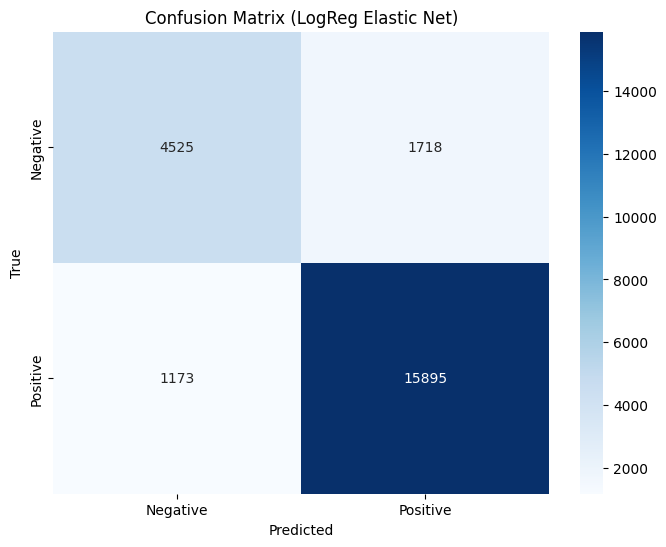

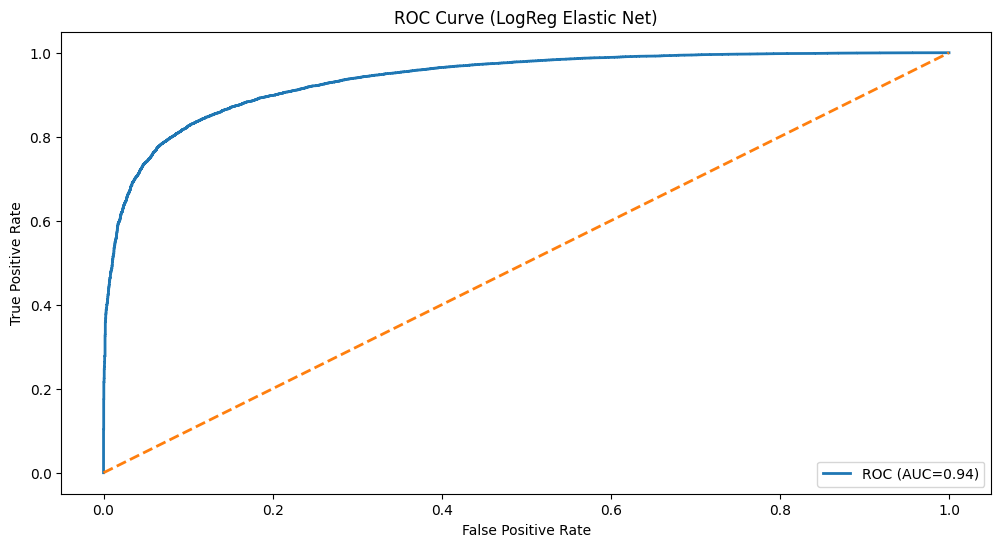

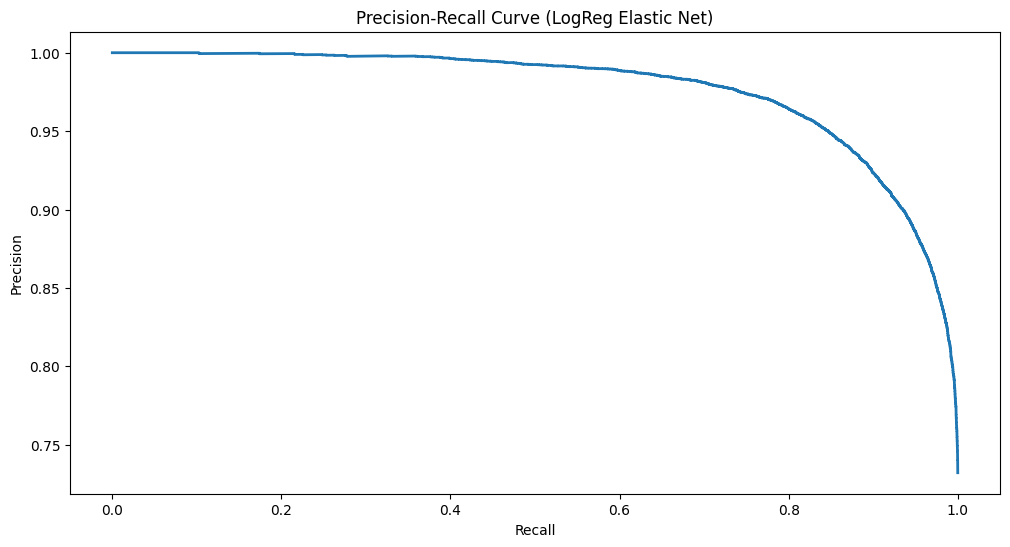

In [ ]:
# GPU Logistic Regression (Elastic Net) with RAPIDS cuML (falls back to sklearn if unavailable)

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ---- load data (same as before) ----
if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find esm_outputs directory at {EMBED_DIR}")

X = np.load(EMBED_DIR / "esm_features.npy").astype(np.float32)  # float32 helps GPU
y = np.load(EMBED_DIR / "labels.npy").astype(np.int32)
metadata = pd.read_csv(EMBED_DIR / "sequence_metadata.csv")
assert len(metadata) == len(X)

idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, stratify=y, random_state=random_seed
)
metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

# ---- try GPU path ----
use_gpu = False
try:
    import cupy as cp
    from cuml.preprocessing import StandardScaler as cuStandardScaler
    from cuml.linear_model import LogisticRegression as cuLogReg
    use_gpu = True
    print("Using GPU: RAPIDS cuML + CuPy")
except Exception as e:
    print("GPU LR not available (RAPIDS not installed). Falling back to sklearn.")
    use_gpu = False

l1_ratio = 0.5
C = 1.0
max_iter = 5000

if use_gpu:
    # Move to GPU
    Xtr = cp.asarray(X_train)
    Xte = cp.asarray(X_test)
    ytr = cp.asarray(y_train)
    yte = cp.asarray(y_test)

    scaler = cuStandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    # cuML uses different hyperparameter names:
    # - C in sklearn corresponds to 1/lambda-ish; cuML uses 'C' too (check version differences)
    # - Elastic net supported via penalty='elasticnet' and l1_ratio in many versions
    clf = cuLogReg(
        penalty="elasticnet",
        l1_ratio=l1_ratio,
        C=C,
        max_iter=max_iter,
        fit_intercept=True,
        tol=1e-6,
    )
    clf.fit(Xtr_s, ytr)

    y_prob = clf.predict_proba(Xte_s)[:, 1]
    y_pred = clf.predict(Xte_s)

    # Bring back to CPU numpy
    y_prob = cp.asnumpy(y_prob)
    y_pred = cp.asnumpy(y_pred)
else:
    from sklearn.linear_model import LogisticRegression

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=l1_ratio,
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            n_jobs=-1,
            random_state=random_seed,
        ))
    ])
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

# ---- metrics + plots ----
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\n=== LogReg Elastic Net Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (LogReg Elastic Net)")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LogReg Elastic Net)")
plt.legend(loc="lower right")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LogReg Elastic Net)")
plt.show()


# RF

Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 93244 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Using GPU Random Forest: RAPIDS cuML + CuPy

=== Random Forest Results ===
Backend : GPU (cuML)
Accuracy: 0.8492
ROC-AUC : 0.9373
PR-AUC  : 0.9764

              precision    recall  f1-score   support

    Negative       0.90      0.49      0.64      6243
    Positive       0.84      0.98      0.90     17068

    accuracy                           0.85     23311
   macro avg       0.87      0.74      0.77     23311
weighted avg       0.86      0.85      0.83     23311



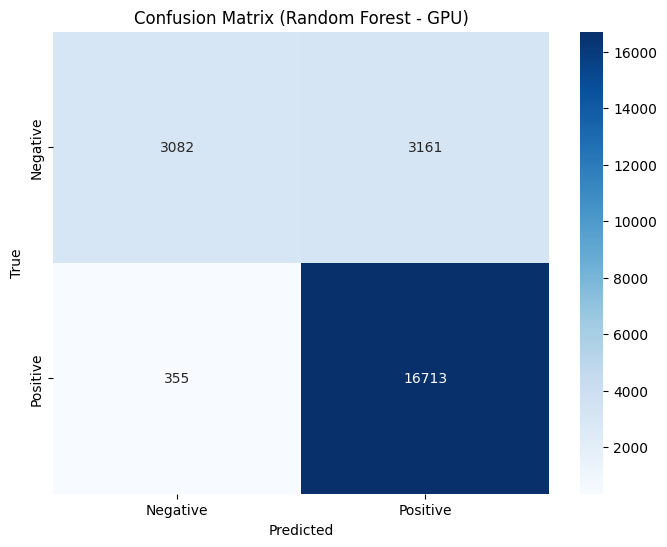

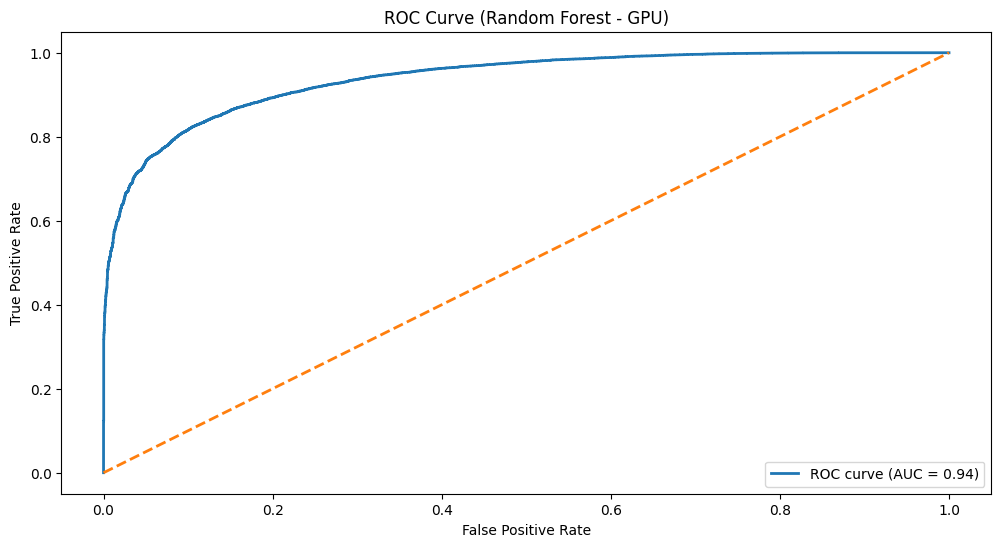

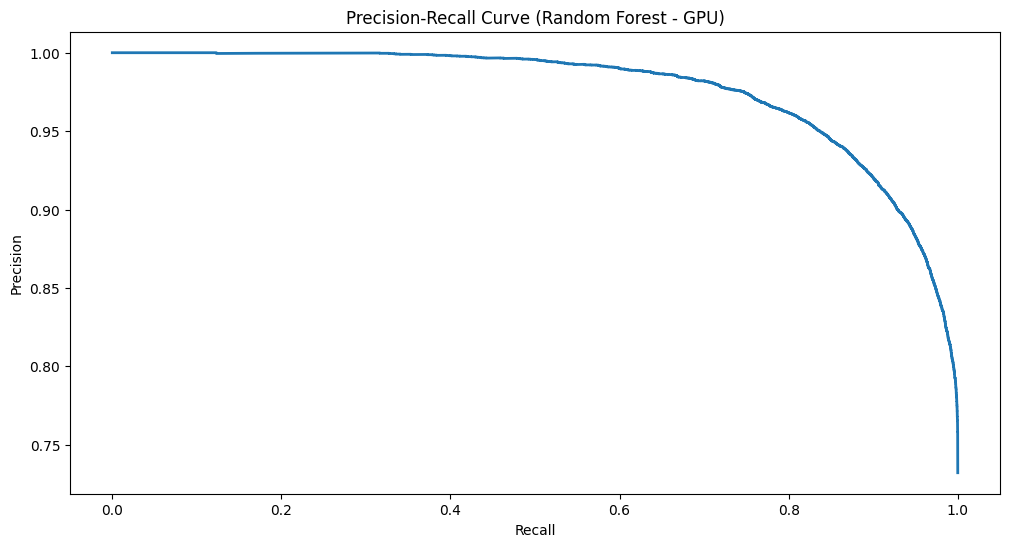

In [ ]:
# Random Forest on ESM embeddings (GPU if RAPIDS cuML available; otherwise CPU sklearn)

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

# ---- Assumptions: defined earlier in your setup cell ----
# random_seed, PROJECT_ROOT, EMBED_DIR
# --------------------------------------------------------

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find esm_outputs directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path = EMBED_DIR / "labels.npy"
metadata_path = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # float32 is best for GPU + fine for CPU
y = np.load(labels_path).astype(np.int32)
metadata = pd.read_csv(metadata_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# Train/test split with aligned metadata indices
indices = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=0.2,
    stratify=y,
    random_state=random_seed,
)
metadata_train = metadata.iloc[idx_train].reset_index(drop=True)
metadata_test  = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# Try GPU Random Forest (RAPIDS)
# -----------------------------
use_gpu = False
rf_model = None

try:
    import cupy as cp
    from cuml.ensemble import RandomForestClassifier as cuRF
    use_gpu = True
    print("Using GPU Random Forest: RAPIDS cuML + CuPy")
except Exception as e:
    print("GPU RF not available (RAPIDS not installed). Falling back to sklearn CPU RF.")
    use_gpu = False

# Hyperparameters (reasonable starting point; adjust based on runtime + accuracy)
n_estimators = 500
max_depth = 16          # limit depth to reduce overfitting and training time
max_features = "sqrt"   # good default
min_samples_leaf = 1

if use_gpu:
    # Move arrays to GPU
    Xtr = cp.asarray(X_train)
    Xte = cp.asarray(X_test)
    ytr = cp.asarray(y_train)

    # cuML RF parameter names can vary slightly by version; these are common.
    # If your environment errors on a parameter, remove it and rerun.
    rf_model = cuRF(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        n_streams=4,        # can improve throughput on A100
        random_state=random_seed,
    )
    rf_model.fit(Xtr, ytr)

    # Probabilities + labels
    y_prob = rf_model.predict_proba(Xte)[:, 1]
    y_pred = rf_model.predict(Xte)

    # Back to CPU numpy for sklearn metrics/plots
    y_prob = cp.asnumpy(y_prob)
    y_pred = cp.asnumpy(y_pred).astype(np.int32)

else:
    from sklearn.ensemble import RandomForestClassifier

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None if max_depth is None else max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=random_seed,
    )
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test).astype(np.int32)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation
# -----------------------------
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\n=== Random Forest Results ===")
print(f"Backend : {'GPU (cuML)' if use_gpu else 'CPU (sklearn)'}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Random Forest - {'GPU' if use_gpu else 'CPU'})")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Random Forest - {'GPU' if use_gpu else 'CPU'})")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Random Forest - {'GPU' if use_gpu else 'CPU'})")
plt.show()

# -----------------------------
# Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_test
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / f"test_predictions_random_forest_{'gpu' if use_gpu else 'cpu'}.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# XGBoost

Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 93244 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
scale_pos_weight (neg/pos) = 0.366
Training XGBoost (GPU)...
[0]	train-auc:0.80602	train-aucpr:0.91452	train-logloss:0.67917	val-auc:0.78486	val-aucpr:0.90368	val-logloss:0.67973
[50]	train-auc:0.93338	train-aucpr:0.97512	train-logloss:0.40863	val-auc:0.90326	val-aucpr:0.96322	val-logloss:0.43363
[100]	train-auc:0.95803	train-aucpr:0.98451	train-logloss:0.32868	val-auc:0.92297	val-aucpr:0.97103	val-logloss:0.37016
[150]	train-auc:0.97199	train-aucpr:0.98973	train-logloss:0.28048	val-auc:0.93339	val-aucpr:0.97508	val-logloss:0.33609
[200]	train-auc:0.98083	train-aucpr:0.99301	train-logloss:0.24559	val-auc:0.93955	val-aucpr:0.97748	val-logloss:0.31398
[250]	train-auc:0.98660	train-aucpr:0.99514	train-logloss:0.21869	val-auc:0.94351	val-aucpr:0.97902	val-logloss:0.29861
[300]	train-auc:0.99050	train-aucpr:0.99657	train-log

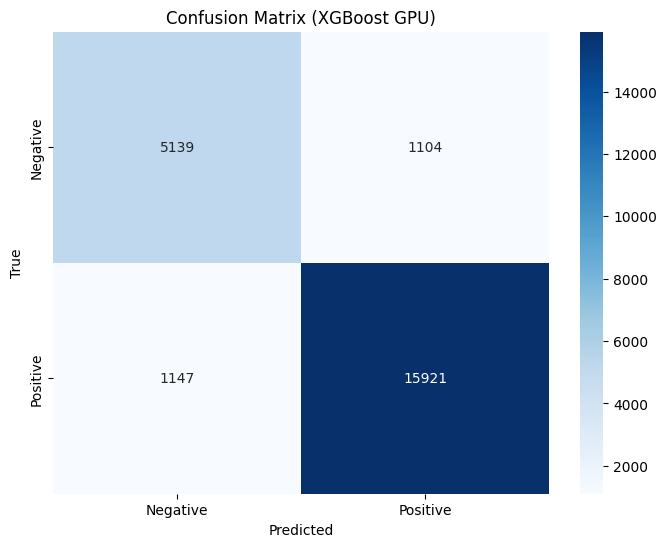

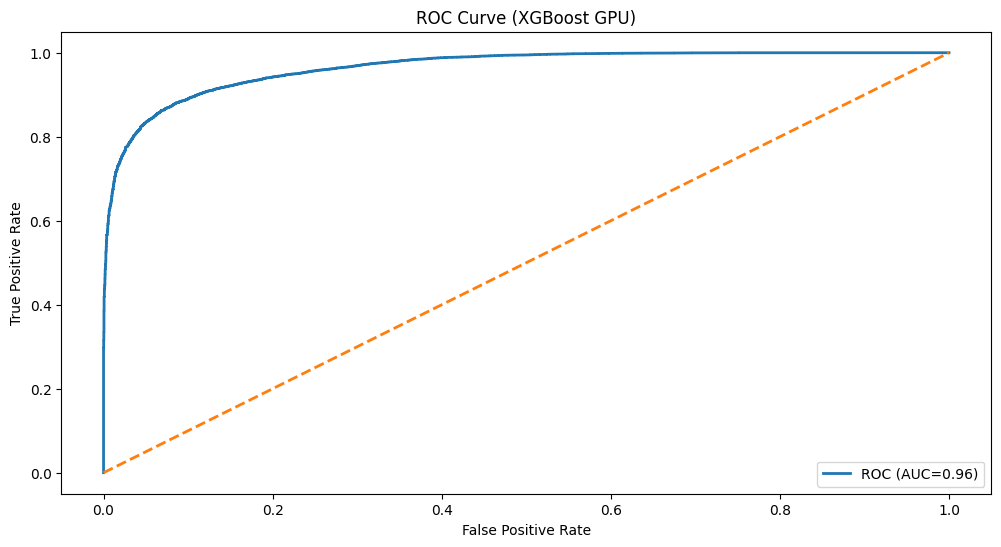

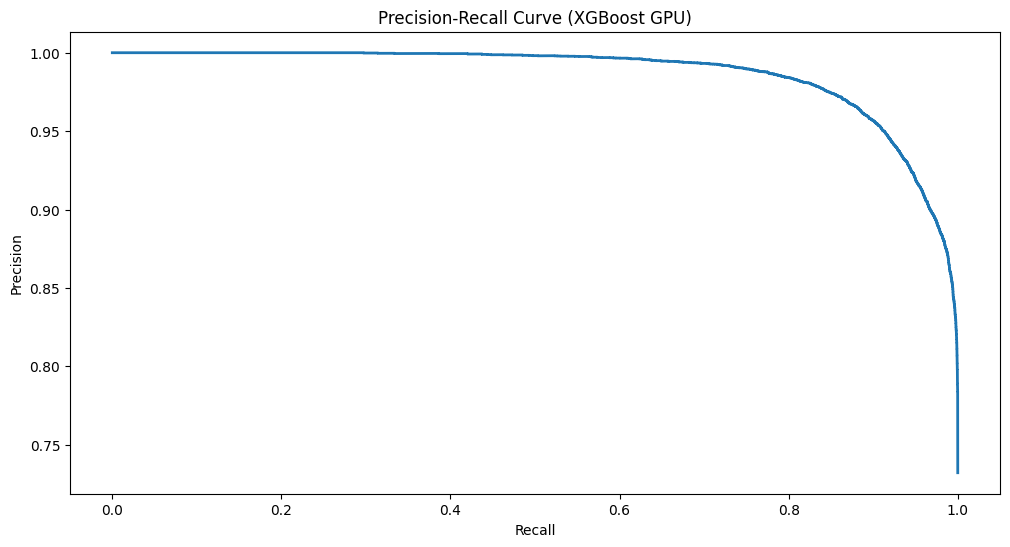

In [ ]:
# XGBoost on GPU (XGBoost 3.x style: tree_method="hist" + device="cuda")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

# ---- Assumptions: EMBED_DIR and random_seed already defined in your setup ----
if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)
y = np.load(labels_path).astype(np.int32)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# Train/test split with aligned metadata indices
idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, stratify=y, random_state=random_seed
)
metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")

# Class imbalance handling
pos = float(np.sum(y_train == 1))
neg = float(np.sum(y_train == 0))
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"scale_pos_weight (neg/pos) = {scale_pos_weight:.3f}")

# Split train -> train/val for early stopping (avoid test leakage)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=random_seed
)

dtrain = xgb.QuantileDMatrix(X_tr, label=y_tr)
dval  = xgb.QuantileDMatrix(X_val, label=y_val, ref=dtrain)
dtest = xgb.QuantileDMatrix(X_test, label=y_test, ref=dtrain)

params = {
    "objective": "binary:logistic",
    "eval_metric": ["auc", "aucpr", "logloss"],

    # GPU selection in XGBoost 2.x/3.x style:
    "tree_method": "hist",
    "device": "cuda",

    # Reasonable starting hyperparameters
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "gamma": 0.0,
    "scale_pos_weight": scale_pos_weight,
    "seed": random_seed,
}

evals = [(dtrain, "train"), (dval, "val")]

num_boost_round = 5000
early_stopping_rounds = 100

print("Training XGBoost (GPU)...")
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=50,
)

best_iter = bst.best_iteration if bst.best_iteration is not None else (num_boost_round - 1)
print(f"Best iteration: {best_iter}")

# Predict on test
y_prob = bst.predict(dtest, iteration_range=(0, best_iter + 1))
y_pred = (y_prob >= 0.5).astype(np.int32)

# Metrics
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\n=== XGBoost GPU Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (XGBoost GPU)")
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost GPU)")
plt.legend(loc="lower right")
plt.show()

# PR
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost GPU)")
plt.show()

# Save model + predictions
# model_path = EMBED_DIR / "xgboost_gpu_model.json"
# bst.save_model(model_path)
# print("Saved model to:", model_path)

# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_test
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_xgboost_gpu.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# SVM Linear

Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 93244 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training Linear SVM + calibration...

=== Linear SVM + Calibration Results ===
Accuracy: 0.8750
ROC-AUC : 0.9381
PR-AUC  : 0.9767

              precision    recall  f1-score   support

    Negative       0.79      0.73      0.76      6243
    Positive       0.90      0.93      0.92     17068

    accuracy                           0.88     23311
   macro avg       0.85      0.83      0.84     23311
weighted avg       0.87      0.88      0.87     23311



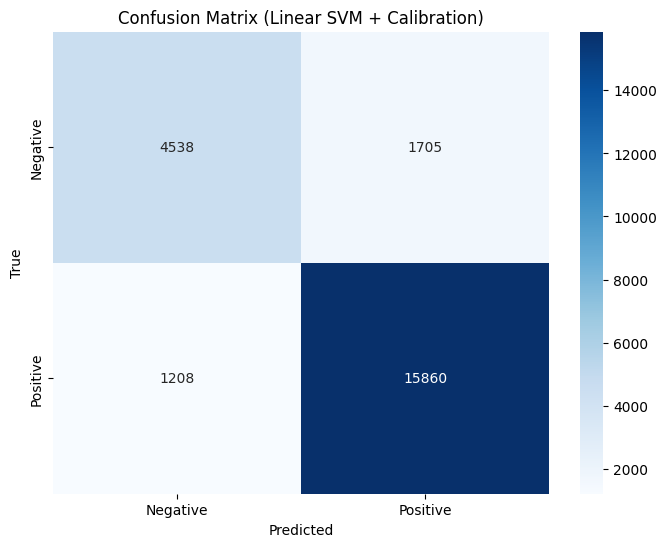

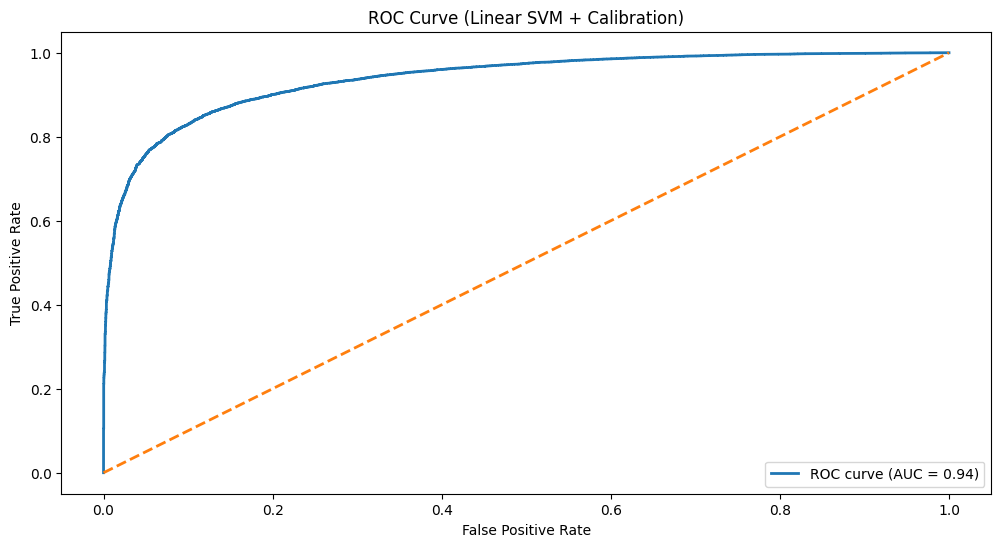

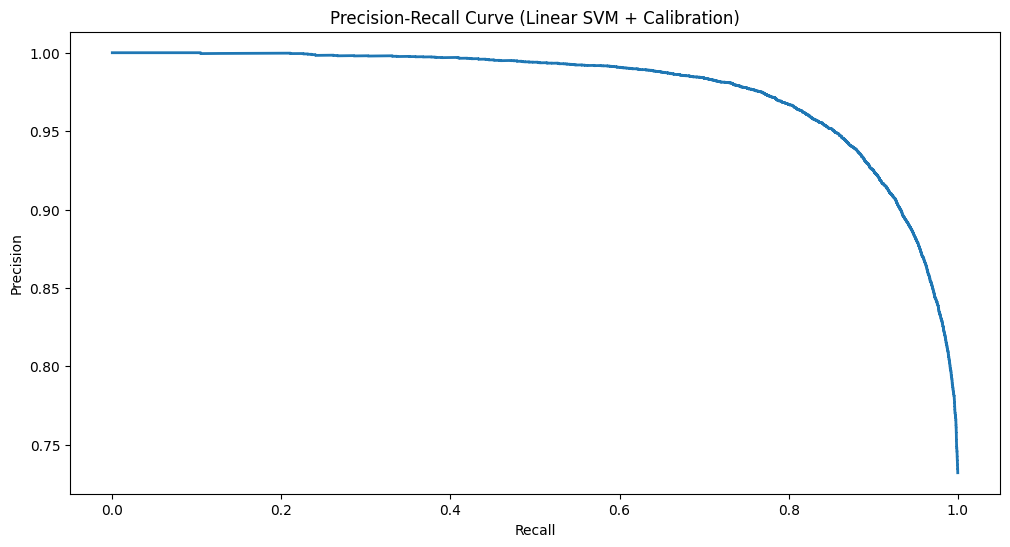

In [ ]:
# Linear SVM + probability calibration on ESM embeddings
# - Uses LinearSVC (fast) + CalibratedClassifierCV (to get probabilities)
# - Trains, evaluates, plots, and saves test predictions aligned with metadata

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # float32 OK; sklearn will cast as needed
y = np.load(labels_path).astype(np.int32)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# Train/test split with aligned metadata indices
idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, stratify=y, random_state=random_seed
)
metadata_train = metadata.iloc[idx_train].reset_index(drop=True)
metadata_test  = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# Linear SVM + Calibration
# -----------------------------
# Notes:
# - LinearSVC does NOT output probabilities; it outputs decision_function scores.
# - CalibratedClassifierCV learns a mapping to probabilities via Platt scaling (sigmoid) or isotonic.
# - For large datasets, sigmoid is usually faster and stable.

C = 1.0
calibration_method = "sigmoid"  # "sigmoid" (Platt scaling) or "isotonic" (slower)
calibration_cv = 3              # internal CV folds used for calibration

base_svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(
        C=C,
        class_weight="balanced",   # helpful if imbalance exists
        random_state=random_seed,
        max_iter=20000,
    ))
])

# Calibrator wraps the whole pipeline (scaler + SVM)
svm_cal = CalibratedClassifierCV(
    estimator=base_svm,
    method=calibration_method,
    cv=calibration_cv,
    n_jobs=-1,
)

print("Training Linear SVM + calibration...")
svm_cal.fit(X_train, y_train)

# Predictions
y_pred = svm_cal.predict(X_test)
y_prob = svm_cal.predict_proba(X_test)[:, 1]  # calibrated probability for positive class

# -----------------------------
# Evaluation
# -----------------------------
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\n=== Linear SVM + Calibration Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Linear SVM + Calibration)")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Linear SVM + Calibration)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Linear SVM + Calibration)")
plt.show()

# -----------------------------
# Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_test
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_linear_svm_calibrated.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 93244 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Fit size: 74595 | Cal size: 18649
Using GPU LinearSVC: RAPIDS cuML + CuPy

=== Linear SVM (+ GPU if available) + Calibration Results ===
Backend : GPU (cuML)
Accuracy: 0.8587
ROC-AUC : 0.9370
PR-AUC  : 0.9753

              precision    recall  f1-score   support

    Negative       0.69      0.87      0.77      6243
    Positive       0.95      0.85      0.90     17068

    accuracy                           0.86     23311
   macro avg       0.82      0.86      0.83     23311
weighted avg       0.88      0.86      0.86     23311



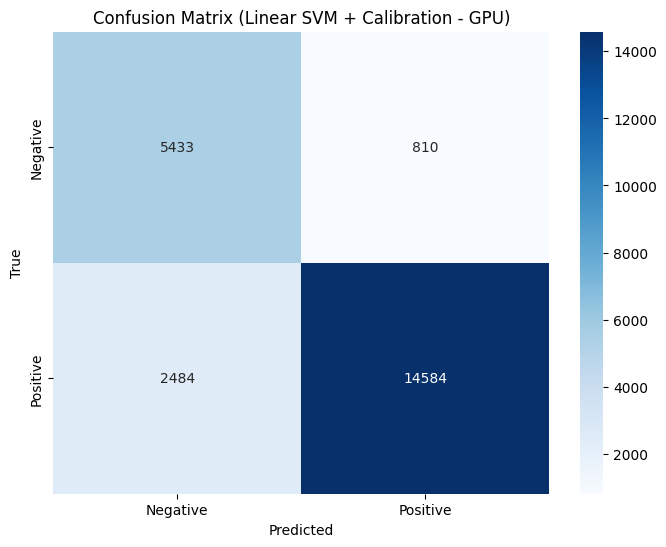

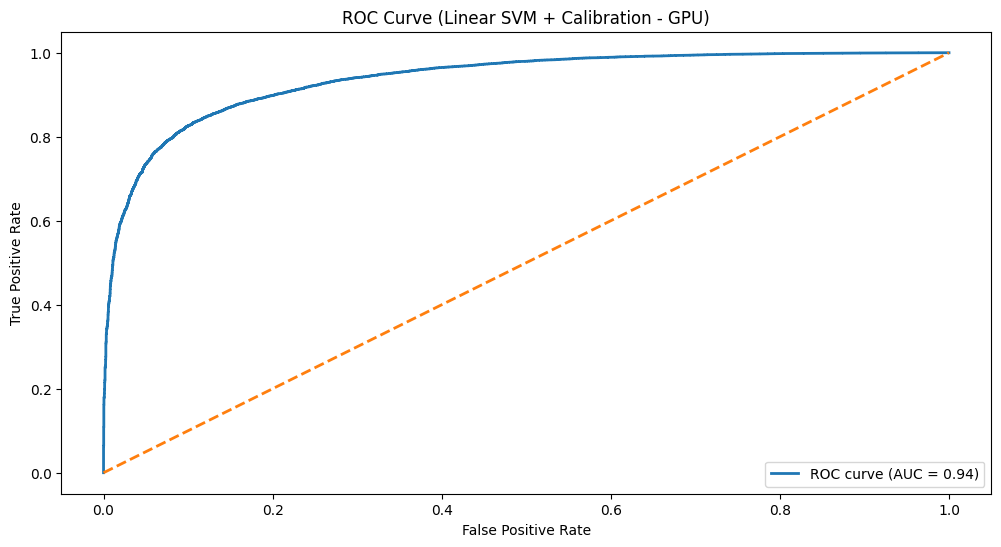

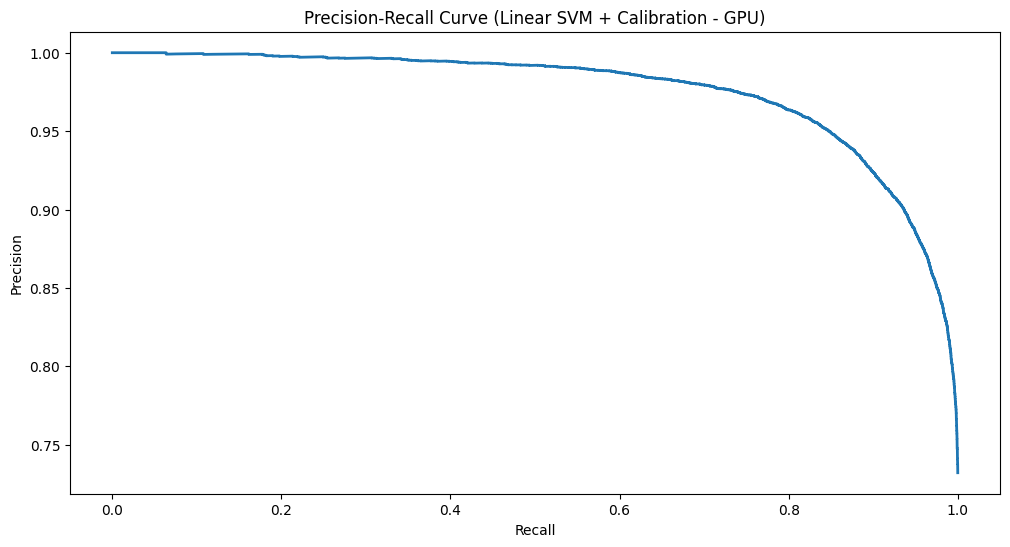

In [ ]:
# Linear SVM + probability calibration
# - Tries GPU SVM via RAPIDS cuML (uses A100)
# - Uses sklearn calibration on CPU using decision scores
# - Falls back to sklearn LinearSVC if cuML is unavailable

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

# ---- Assumptions: EMBED_DIR and random_seed already defined ----
if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)
y = np.load(labels_path).astype(np.int32)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# Train/test split with aligned metadata indices
idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, stratify=y, random_state=random_seed
)
metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")

# Split off a calibration set from the training set to avoid calibrating on test
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=random_seed
)
print(f"Fit size: {len(X_fit)} | Cal size: {len(X_cal)}")

# Standardize (important for SVM)
scaler = StandardScaler(with_mean=True, with_std=True)
X_fit_s = scaler.fit_transform(X_fit)
X_cal_s = scaler.transform(X_cal)
X_test_s = scaler.transform(X_test)

# -----------------------------
# Try GPU linear SVM (cuML)
# -----------------------------
use_gpu = False
svm_model = None

try:
    import cupy as cp
    from cuml.svm import LinearSVC as cuLinearSVC
    use_gpu = True
    print("Using GPU LinearSVC: RAPIDS cuML + CuPy")
except Exception:
    print("GPU LinearSVC not available (RAPIDS not installed). Falling back to sklearn.")
    use_gpu = False

C = 1.0

if use_gpu:
    # Move scaled features to GPU
    X_fit_g = cp.asarray(X_fit_s)
    y_fit_g = cp.asarray(y_fit.astype(np.int32))

    # cuML LinearSVC returns a margin score via decision_function (version dependent).
    # If decision_function is unavailable in your cuML version, we use predict and treat outputs as labels.
    svm_model = cuLinearSVC(C=C, max_iter=20000, tol=1e-4)
    svm_model.fit(X_fit_g, y_fit_g)

    # Get decision scores for calibration (prefer decision_function if available)
    try:
        cal_scores = svm_model.decision_function(cp.asarray(X_cal_s))
        test_scores = svm_model.decision_function(cp.asarray(X_test_s))
        cal_scores = cp.asnumpy(cal_scores).reshape(-1, 1)
        test_scores = cp.asnumpy(test_scores).reshape(-1, 1)
    except Exception:
        # Fallback: use signed distance approximated by converting predictions {0,1} -> {-1,+1}
        cal_pred = cp.asnumpy(svm_model.predict(cp.asarray(X_cal_s))).astype(np.int32)
        test_pred = cp.asnumpy(svm_model.predict(cp.asarray(X_test_s))).astype(np.int32)
        cal_scores = (2 * cal_pred - 1).reshape(-1, 1).astype(np.float32)
        test_scores = (2 * test_pred - 1).reshape(-1, 1).astype(np.float32)

else:
    from sklearn.svm import LinearSVC

    svm_model = LinearSVC(
        C=C,
        class_weight="balanced",
        random_state=random_seed,
        max_iter=20000,
    )
    svm_model.fit(X_fit_s, y_fit)

    cal_scores = svm_model.decision_function(X_cal_s).reshape(-1, 1)
    test_scores = svm_model.decision_function(X_test_s).reshape(-1, 1)

# -----------------------------
# Calibration (CPU): Platt scaling via LogisticRegression on decision scores
# -----------------------------
# This is effectively the same idea as CalibratedClassifierCV(method="sigmoid"),
# but we do it explicitly so it works with GPU SVM decision scores too.

calibrator = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    class_weight="balanced",
    random_state=random_seed,
)
calibrator.fit(cal_scores, y_cal)

y_prob = calibrator.predict_proba(test_scores)[:, 1]
y_pred = (y_prob >= 0.5).astype(np.int32)

# -----------------------------
# Evaluation
# -----------------------------
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\n=== Linear SVM (+ GPU if available) + Calibration Results ===")
print(f"Backend : {'GPU (cuML)' if use_gpu else 'CPU (sklearn)'}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Linear SVM + Calibration - {'GPU' if use_gpu else 'CPU'})")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Linear SVM + Calibration - {'GPU' if use_gpu else 'CPU'})")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Linear SVM + Calibration - {'GPU' if use_gpu else 'CPU'})")
plt.show()

# Save predictions aligned with metadata_test
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_test
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / f"test_predictions_linear_svm_calibrated_{'gpu' if use_gpu else 'cpu'}.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# Baseline Models(DL)

# CNN

In [ ]:
# CNN classifier on ESM mean-pooled embeddings (vector -> 2D "stripe" conv)
# - Matches the style of the LR/XGBoost cells: load -> split -> train (early stop) -> evaluate -> plot -> save
# - Uses GPU (A100) automatically via torch.cuda if available
# - Uses a proper train/val split for early stopping (no test leakage)

print(f"Using device: {device}")

# -----------------------------
# Load embeddings
# -----------------------------
# Assumes EMBED_DIR is already defined in your setup cell.
# If not, uncomment and set it:
# EMBED_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding")

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# -----------------------------
# Train/val/test split (aligned indices)
# -----------------------------
indices = np.arange(len(y))

# First split: train_temp vs test
X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)

# Second split: train vs val (from train_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1 - y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# CNN expects input: (B, 1, D, 1)  (same convention as your reference CNN)
# -----------------------------
X_train_t = torch.tensor(X_train.reshape(-1, 1, X_train.shape[1], 1), dtype=torch.float32)
X_val_t   = torch.tensor(X_val.reshape(-1, 1, X_val.shape[1], 1), dtype=torch.float32)
X_test_t  = torch.tensor(X_test.reshape(-1, 1, X_test.shape[1], 1), dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

# -----------------------------
# Model (based on your reference)
# -----------------------------
class DeeperCNNClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int = 2, dropout_p: float = 0.2978):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 79, kernel_size=(3, 1))
        self.bn1 = nn.BatchNorm2d(79)

        self.conv2 = nn.Conv2d(79, 111, kernel_size=(7, 1))
        self.bn2 = nn.BatchNorm2d(111)

        self.conv3 = nn.Conv2d(111, 180, kernel_size=(6, 1))
        self.bn3 = nn.BatchNorm2d(180)

        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        self.flatten_dim = self._get_flatten_dim(input_dim)

        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(dropout_p)

    def _get_flatten_dim(self, input_dim: int) -> int:
        with torch.no_grad():
            x = torch.zeros(1, 1, input_dim, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = F.relu(self.bn3(self.conv3(x)))
            return x.numel()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)
        return logits  # raw logits (use CrossEntropyLoss)

input_dim = X_train.shape[1]
model = DeeperCNNClassifier(input_dim=input_dim, num_classes=2).to(device)

# -----------------------------
# Loss: handle imbalance via class weights
# -----------------------------
# weight[c] = N / (2 * N_c) is a common simple weighting
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=4.575e-05, weight_decay=1e-3)

# -----------------------------
# Training loop with early stopping on val ROC-AUC
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
early_stop_counter = 0

ckpt_dir = EMBED_DIR / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / "best_cnn_model.pth"

def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)
    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

print("Training CNN...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation (load best checkpoint)
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)

acc = accuracy_score(y_true, y_pred)

print("\n=== CNN Results (Test) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CNN)")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (CNN)")
plt.show()

# -----------------------------
# Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_cnn.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


Using device: cuda
Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training CNN...


NameError: name 'average_precision_score' is not defined

# RNN

Using device: cuda
Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training GRU (RNN)...


Epoch 01 | Train Loss 0.3736 Acc 0.8111 | Val Loss 0.3234 ROC-AUC 0.9387 PR-AUC 0.9773
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_gru_model.pth


Epoch 02 | Train Loss 0.2949 Acc 0.8565 | Val Loss 0.2912 ROC-AUC 0.9475 PR-AUC 0.9806
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_gru_model.pth


Epoch 03 | Train Loss 0.2641 Acc 0.8708 | Val Loss 0.2627 ROC-AUC 0.9569 PR-AUC 0.9841
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_gru_model.pth


Epoch 04 | Train Loss 0.2446 Acc 0.8798 | Val Loss 0.2534 ROC-AUC 0.9606 PR-AUC 0.9855
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_gru_model.pth


...

Epoch 13 | Train Loss 0.1507 Acc 0.9267 | Val Loss 0.2675 ROC-AUC 0.9673 PR-AUC 0.9876


Epoch 14 | Train Loss 0.1445 Acc 0.9293 | Val Loss 0.2907 ROC-AUC 0.9666 PR-AUC 0.9874


Epoch 15 | Train Loss 0.1370 Acc 0.9322 | Val Loss 0.2622 ROC-AUC 0.9655 PR-AUC 0.9870


Epoch 16 | Train Loss 0.1300 Acc 0.9363 | Val Loss 0.2911 ROC-AUC 0.9679 PR-AUC 0.9879


Epoch 17 | Train Loss 0.1219 Acc 0.9400 | Val Loss 0.3062 ROC-AUC 0.9669 PR-AUC 0.9875
Early stopping triggered
Loading best model: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_gru_model.pth

=== GRU (RNN) Results (Test) ===
Accuracy: 0.8938
ROC-AUC : 0.9701
PR-AUC  : 0.9887

              precision    recall  f1-score   support

    Negative       0.74      0.93      0.82      6243
    Positive       0.97      0.88      0.92     17068

    accuracy                           0.89     23311
   macro avg       0.86      0.91      0.87     23311
weighted avg       0.91      0.89      0.90     23311



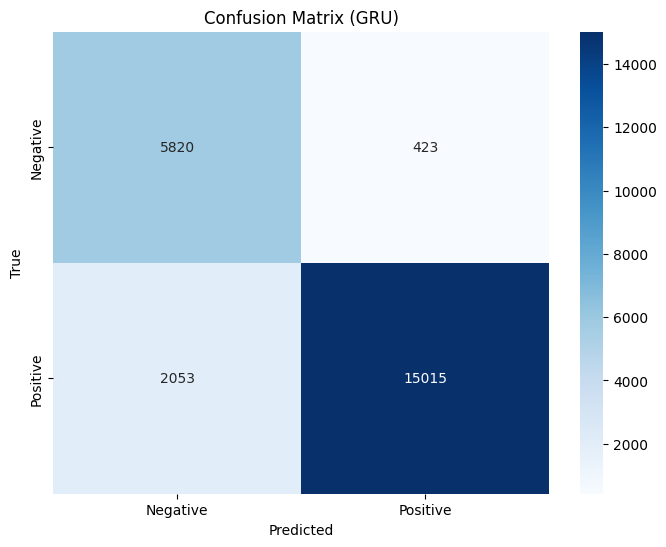

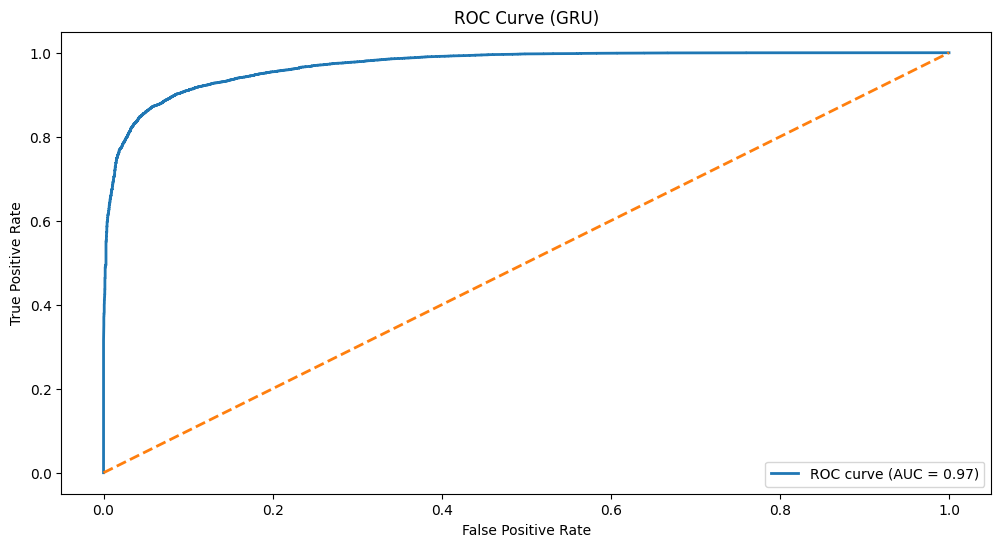

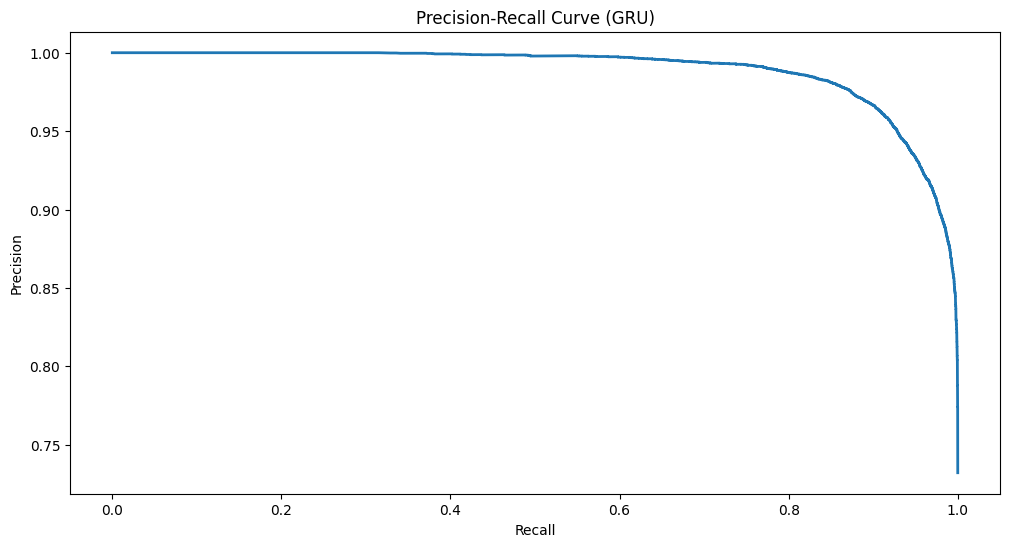

In [ ]:
# RNN (GRU) classifier on ESM mean-pooled embeddings (vector treated as a 1-step sequence)
# - Same style as LR/XGBoost/CNN cells: load -> split -> train (early stop) -> evaluate -> plot -> save
# - Uses GPU automatically
# - IMPORTANT: With seq_len=1, an RNN is effectively a fancy MLP. This mirrors your prior LSTM setup.
#   If you want a true RNN over residues, we must use per-residue embeddings instead of mean-pooled vectors.

print(f"Using device: {device}")

# -----------------------------
# Load embeddings
# -----------------------------
# Assumes EMBED_DIR is already defined in your setup cell.
# If not, uncomment and set it:
# EMBED_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding")

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# -----------------------------
# Train/val/test split (aligned indices)
# -----------------------------
indices = np.arange(len(y))

X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1 - y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# Reshape for RNN input: (B, T, D)
# Here we keep T=1 to match your prior LSTM pipeline on pooled embeddings.
# -----------------------------
seq_len = 1
D = X_train.shape[1]

X_train_t = torch.tensor(X_train.reshape(-1, seq_len, D), dtype=torch.float32)
X_val_t   = torch.tensor(X_val.reshape(-1, seq_len, D), dtype=torch.float32)
X_test_t  = torch.tensor(X_test.reshape(-1, seq_len, D), dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=512, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

# -----------------------------
# Model: GRU-based classifier (RNN family)
# -----------------------------
class GRUClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 256, num_layers: int = 2, dropout_p: float = 0.3, num_classes: int = 2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(hidden_dim * 2, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)          # (B, T, 2H)
        out = out[:, -1, :]           # last time step (B, 2H)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        logits = self.fc2(out)
        return logits

model = GRUClassifier(input_dim=D, hidden_dim=256, num_layers=2, dropout_p=0.3, num_classes=2).to(device)

# -----------------------------
# Loss: handle imbalance via class weights
# -----------------------------
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# -----------------------------
# Training loop with early stopping on val ROC-AUC
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
early_stop_counter = 0

ckpt_dir = EMBED_DIR / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / "best_gru_model.pth"

def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)
    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

print("Training GRU (RNN)...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation (load best checkpoint)
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)

acc = accuracy_score(y_true, y_pred)

print("\n=== GRU (RNN) Results (Test) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (GRU)")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GRU)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (GRU)")
plt.show()

# -----------------------------
# Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_gru.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# RNN Chuck

Using device: cuda
Loading chunk-pooled embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/esm_chunkmean_K8.npy
X shape: (116555, 8, 1280) (N, K, D) = (116555, 8, 1280)
Label balance: pos=0.732, neg=0.268
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training BiGRU on chunk-pooled embeddings...


Epoch 01 | Train Loss 0.3588 Acc 0.8169 | Val Loss 0.3001 ROC-AUC 0.9434 PR-AUC 0.9791
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_bigru_chunkK8.pth


Epoch 02 | Train Loss 0.2710 Acc 0.8677 | Val Loss 0.2608 ROC-AUC 0.9572 PR-AUC 0.9841
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_bigru_chunkK8.pth


Epoch 03 | Train Loss 0.2369 Acc 0.8846 | Val Loss 0.2489 ROC-AUC 0.9621 PR-AUC 0.9858
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_bigru_chunkK8.pth


Epoch 04 | Train Loss 0.2138 Acc 0.8969 | Val Loss 0.2865 ROC-AUC 0.9635 PR-AUC 0.9865
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_bigru_chunkK8.pth


...

Epoch 10 | Train Loss 0.1246 Acc 0.9390 | Val Loss 0.3498 ROC-AUC 0.9674 PR-AUC 0.9878


Epoch 11 | Train Loss 0.1103 Acc 0.9455 | Val Loss 0.3263 ROC-AUC 0.9669 PR-AUC 0.9874


Epoch 12 | Train Loss 0.1032 Acc 0.9497 | Val Loss 0.3457 ROC-AUC 0.9656 PR-AUC 0.9872


Epoch 13 | Train Loss 0.0937 Acc 0.9545 | Val Loss 0.3672 ROC-AUC 0.9653 PR-AUC 0.9870


Epoch 14 | Train Loss 0.0847 Acc 0.9582 | Val Loss 0.4056 ROC-AUC 0.9659 PR-AUC 0.9873
Early stopping triggered
Loading best model: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_bigru_chunkK8.pth

=== BiGRU (Chunk-pooled) Results (Test) ===
Accuracy: 0.8959
ROC-AUC : 0.9695
PR-AUC  : 0.9885

              precision    recall  f1-score   support

    Negative       0.74      0.93      0.83      6243
    Positive       0.97      0.88      0.93     17068

    accuracy                           0.90     23311
   macro avg       0.86      0.91      0.88     23311
weighted avg       0.91      0.90      0.90     23311



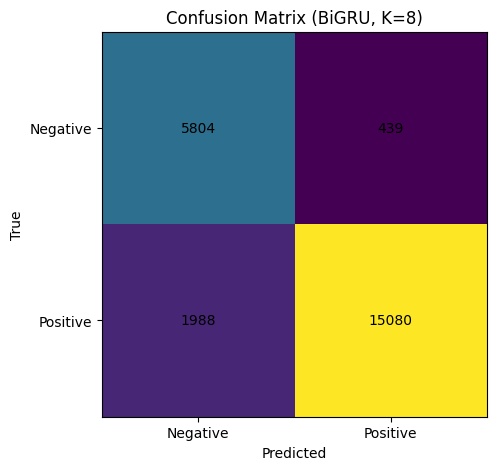

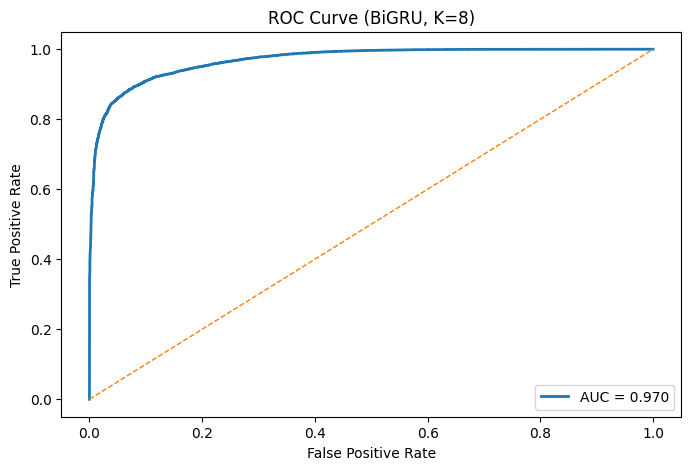

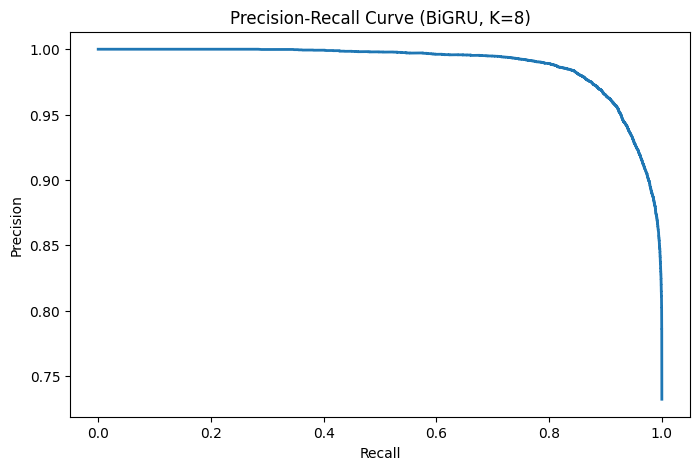

In [ ]:
# =============================
# RNN (GRU) classifier on chunk-pooled ESM embeddings (N, K, D) where K=8
# - load -> split -> train (early stop on val ROC-AUC) -> evaluate -> plot -> save
# - Uses GPU automatically
# =============================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

import matplotlib.pyplot as plt

print(f"Using device: {device}")

# -----------------------------
# Paths: chunk-pooled features
# -----------------------------
K = 8
chunk_dir = EMBED_DIR / "chunk_pooled"
features_path = chunk_dir / f"esm_chunkmean_K{K}.npy"
labels_path   = chunk_dir / "labels.npy"
meta_path     = chunk_dir / "sequence_metadata.csv"

for p in [features_path, labels_path, meta_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Loading chunk-pooled embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, K, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")
if X.ndim != 3 or X.shape[1] != K:
    raise ValueError(f"Expected X shape (N, {K}, D), got {X.shape}")

N, K_loaded, D = X.shape
print(f"X shape: {X.shape} (N, K, D) = ({N}, {K_loaded}, {D})")
print(f"Label balance: pos={y.mean():.3f}, neg={1-y.mean():.3f}")

# -----------------------------
# Train/val/test split (aligned indices)
# -----------------------------
indices = np.arange(len(y))

X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1-y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1-y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1-y_test.mean():.3f}")

# -----------------------------
# Tensors / DataLoaders
# -----------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)  # (B, K, D)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=512, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=512, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available()
)

# -----------------------------
# Model: BiGRU classifier over K chunks
# -----------------------------
class ChunkBiGRUClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 256, num_layers: int = 2,
                 dropout_p: float = 0.3, num_classes: int = 2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(hidden_dim * 2, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (B, K, D)
        out, _ = self.gru(x)          # (B, K, 2H)
        out = out[:, -1, :]           # last step (B, 2H)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        logits = self.fc2(out)
        return logits

model = ChunkBiGRUClassifier(input_dim=D, hidden_dim=256, num_layers=2, dropout_p=0.3, num_classes=2).to(device)

# -----------------------------
# Loss: handle imbalance via class weights
# -----------------------------
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# -----------------------------
# Eval helper
# -----------------------------
def eval_loader(loader):
    model.eval()
    all_probs, all_true = [], []
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)
    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

# -----------------------------
# Train with early stopping on val ROC-AUC
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
early_stop_counter = 0

ckpt_dir = chunk_dir / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / f"best_bigru_chunkK{K}.pth"

print("Training BiGRU on chunk-pooled embeddings...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)
    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation (load best checkpoint)
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)
acc = accuracy_score(y_true, y_pred)

print("\n=== BiGRU (Chunk-pooled) Results (Test) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix (BiGRU, K={K})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {test_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (BiGRU, K={K})")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (BiGRU, K={K})")
plt.show()

# -----------------------------
# (Optional) Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob
# out_csv = chunk_dir / f"test_predictions_bigru_chunkK{K}.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# LSTM

In [ ]:
# LSTM classifier on ESM mean-pooled embeddings (vector treated as a 1-step sequence)
# - Same style as LR/XGBoost/CNN/GRU cells: load -> split -> train (early stop) -> evaluate -> plot -> save
# - Uses GPU automatically (A100)
# - Matches your LSTM reference structurally, but FIXES a common issue:
#   your reference returns log_softmax while using CrossEntropyLoss (mismatch).
#   Here we return raw logits + use CrossEntropyLoss (correct).

print(f"Using device: {device}")

# -----------------------------
# Load embeddings
# -----------------------------
# Assumes EMBED_DIR is already defined in your setup cell.
# If not, uncomment and set it:
# from pathlib import Path
# EMBED_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding")

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# -----------------------------
# Train/val/test split (aligned indices)
# -----------------------------
indices = np.arange(len(y))

X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1 - y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# Reshape for LSTM input: (B, T, D)
# Keep T=1 to match your reference LSTM pipeline on pooled embeddings.
# -----------------------------
seq_len = 1
D = X_train.shape[1]

X_train_t = torch.tensor(X_train.reshape(-1, seq_len, D), dtype=torch.float32)
X_val_t   = torch.tensor(X_val.reshape(-1, seq_len, D), dtype=torch.float32)
X_test_t  = torch.tensor(X_test.reshape(-1, seq_len, D), dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=128, shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=512, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=512, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# -----------------------------
# Model (aligned with your reference: unidirectional LSTM + dropout + FC)
# -----------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout_rate):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T, D)
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))      # (B, T, H)
        out = out[:, -1, :]                  # last time step (B, H)
        out = self.dropout(out)
        logits = self.fc(out)                # (B, C) raw logits
        return logits

# Hyperparams (close to reference; adjust if needed)
hidden_dim = 256
num_layers = 2
dropout_rate = 0.3
num_classes = 2
learning_rate = 1.53e-4  # your reference used ~0.000153

model = LSTMClassifier(D, hidden_dim, num_layers, num_classes, dropout_rate).to(device)

# -----------------------------
# Loss: handle imbalance via class weights
# -----------------------------
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# -----------------------------
# Helpers: evaluation
# -----------------------------
def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)

    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

# -----------------------------
# Training loop with early stopping on val loss (matches your reference),
# while also printing val ROC-AUC/PR-AUC for consistency with other cells.
# -----------------------------
n_epochs = 50
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0

ckpt_dir = EMBED_DIR / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / "best_lstm_model.pth"

print("Training LSTM...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}"
    )

    # Early stop based on val loss (reference style)
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation (load best checkpoint)
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)

acc = accuracy_score(y_true, y_pred)

print("\n=== LSTM Results (Test) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (LSTM)")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LSTM)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LSTM)")
plt.show()

# -----------------------------
# Save predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_lstm.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


Using device: cuda
Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training LSTM...


NameError: name 'average_precision_score' is not defined

# BiLSTM

Using device: cuda | AMP: True
Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training BiLSTM...


Epoch 01 | Train Loss 0.3917 Acc 0.8034 | Val Loss 0.3492 ROC-AUC 0.9280 PR-AUC 0.9731
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_bilstm_model.pth


Epoch 02 | Train Loss 0.3108 Acc 0.8543 | Val Loss 0.3023 ROC-AUC 0.9429 PR-AUC 0.9788
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_bilstm_model.pth


Epoch 03 | Train Loss 0.2785 Acc 0.8709 | Val Loss 0.2767 ROC-AUC 0.9516 PR-AUC 0.9821
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_bilstm_model.pth


Epoch 04 | Train Loss 0.2573 Acc 0.8797 | Val Loss 0.2660 ROC-AUC 0.9557 PR-AUC 0.9835
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_bilstm_model.pth


...

Epoch 19 | Train Loss 0.1270 Acc 0.9441 | Val Loss 0.3016 ROC-AUC 0.9633 PR-AUC 0.9854


Epoch 20 | Train Loss 0.1220 Acc 0.9456 | Val Loss 0.3702 ROC-AUC 0.9624 PR-AUC 0.9838


Epoch 21 | Train Loss 0.1159 Acc 0.9488 | Val Loss 0.3229 ROC-AUC 0.9640 PR-AUC 0.9850


Epoch 22 | Train Loss 0.1103 Acc 0.9507 | Val Loss 0.3092 ROC-AUC 0.9632 PR-AUC 0.9850


Epoch 23 | Train Loss 0.1084 Acc 0.9518 | Val Loss 0.3589 ROC-AUC 0.9622 PR-AUC 0.9838
Early stopping triggered
Loading best model: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_bilstm_model.pth

=== BiLSTM Results (Test) ===
Accuracy: 0.9115
ROC-AUC : 0.9684
PR-AUC  : 0.9875

              precision    recall  f1-score   support

    Negative       0.80      0.89      0.84      6243
    Positive       0.96      0.92      0.94     17068

    accuracy                           0.91     23311
   macro avg       0.88      0.90      0.89     23311
weighted avg       0.92      0.91      0.91     23311



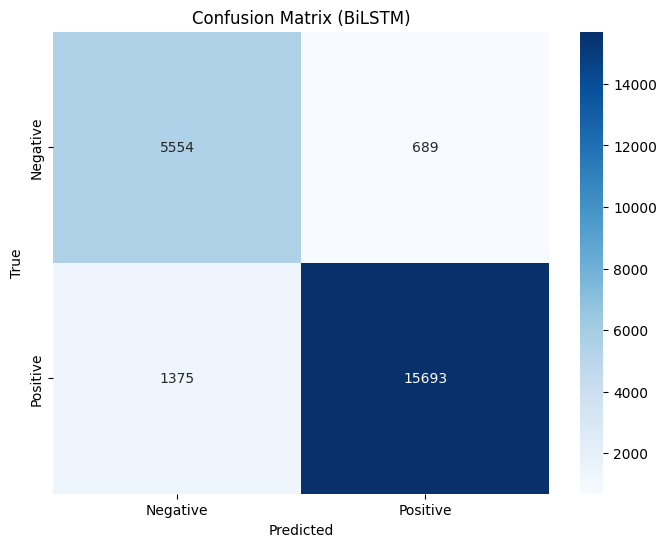

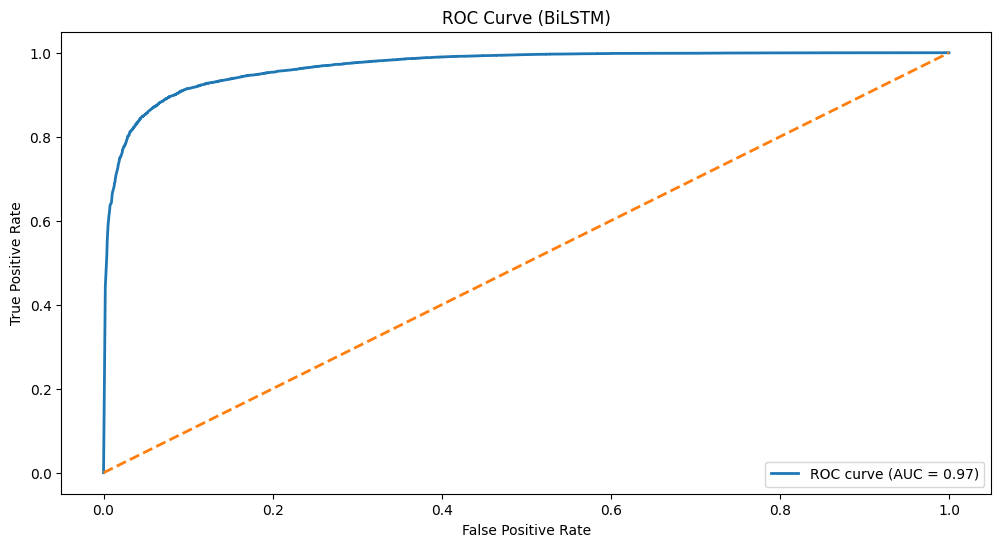

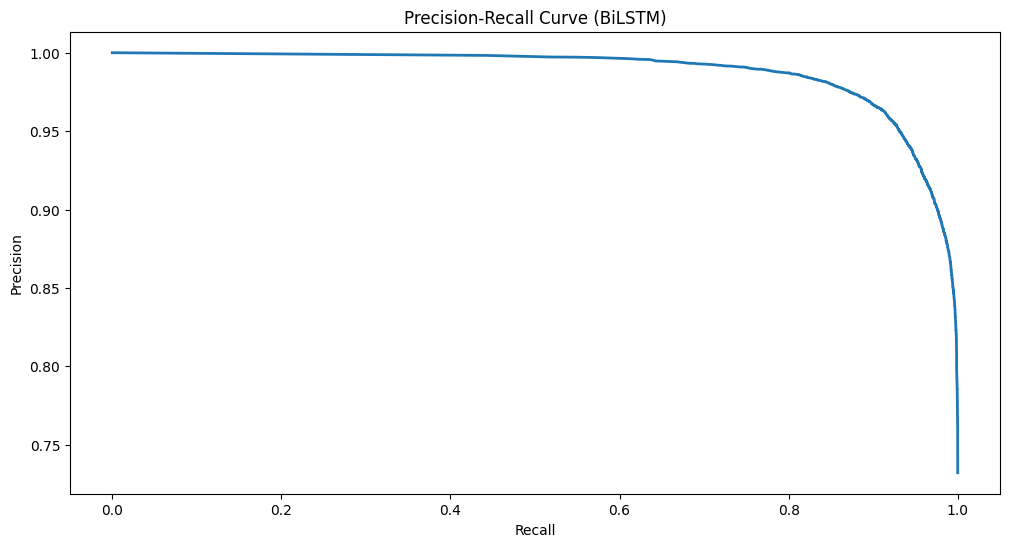

In [ ]:
# BiLSTM classifier on ESM mean-pooled embeddings (vector treated as a 1-step sequence)
# - Same style as LR/XGBoost cells: load -> split -> train (early stop) -> evaluate -> plot -> save
# - Uses GPU automatically (A100). Uses AMP (mixed precision) on CUDA for speed.
# - Updated to the NEW AMP API: torch.amp.autocast / torch.amp.GradScaler (removes FutureWarning)
# - NOTE: seq_len=1 means this is not a “true” sequence BiLSTM over residues; it matches your pooled-embedding pipeline.

use_amp = (device.type == "cuda")
print(f"Using device: {device} | AMP: {use_amp}")

# -----------------------------
# Load embeddings
# -----------------------------
# Assumes EMBED_DIR is already defined in your setup cell, e.g.:
# from pathlib import Path
# EMBED_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

# -----------------------------
# Split: train/val/test
# -----------------------------
indices = np.arange(len(y))

X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1 - y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1 - y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1 - y_test.mean():.3f}")

# -----------------------------
# Reshape for BiLSTM input: (B, T, D), with T=1
# -----------------------------
seq_len = 1
D = X_train.shape[1]

X_train_t = torch.tensor(X_train.reshape(-1, seq_len, D), dtype=torch.float32)
X_val_t   = torch.tensor(X_val.reshape(-1, seq_len, D), dtype=torch.float32)
X_test_t  = torch.tensor(X_test.reshape(-1, seq_len, D), dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True, num_workers=2,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)

# -----------------------------
# Model: BiLSTM + BN + Dropout + FC
# -----------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=2, dropout_rate=0.3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)     # (B, T, 2H)
        out = out[:, -1, :]       # (B, 2H)
        out = self.bn(out)
        out = self.dropout(out)
        logits = self.fc(out)     # raw logits
        return logits

model = BiLSTMClassifier(input_dim=D, hidden_dim=256, num_layers=2, dropout_rate=0.3, num_classes=2).to(device)

# -----------------------------
# Loss (class weights for imbalance)
# -----------------------------
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# NEW AMP API
scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# -----------------------------
# Eval helper
# -----------------------------
@torch.no_grad()
def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        total_n += yb.size(0)

        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)

    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

# -----------------------------
# Train with early stopping (monitor val ROC-AUC; tie-break on val loss)
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
best_val_loss = float("inf")
early_stop_counter = 0

ckpt_dir = EMBED_DIR / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / "best_bilstm_model.pth"

print("Training BiLSTM...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}"
    )

    improved = (val_auc > best_val_auc + 1e-6) or (
        abs(val_auc - best_val_auc) <= 1e-6 and val_loss < best_val_loss - 1e-6
    )

    if improved:
        best_val_auc = val_auc
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation (load best)
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)
acc = accuracy_score(y_true, y_pred)

print("\n=== BiLSTM Results (Test) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (BiLSTM)")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (BiLSTM)")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (BiLSTM)")
plt.show()

# -----------------------------
# Save test predictions aligned with metadata_test
# -----------------------------
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = EMBED_DIR / "test_predictions_bilstm.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


# BiLSTM Chuck

Using device: cuda | AMP: True
Loading features from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/esm_chunkmean_K8.npy
X_chunk shape: (116555, 8, 1280) (N, K, D)
Label balance: pos=0.732, neg=0.268
Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Training Chunk-BiLSTM (K=8)...


Epoch 01 | Train Loss 0.3753 Acc 0.8146 | Val Loss 0.3241 ROC-AUC 0.9397 PR-AUC 0.9773
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_chunk_bilstm_K8.pth


Epoch 02 | Train Loss 0.2825 Acc 0.8657 | Val Loss 0.2735 ROC-AUC 0.9538 PR-AUC 0.9828
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_chunk_bilstm_K8.pth


Epoch 03 | Train Loss 0.2465 Acc 0.8833 | Val Loss 0.2610 ROC-AUC 0.9586 PR-AUC 0.9846
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_chunk_bilstm_K8.pth


Epoch 04 | Train Loss 0.2234 Acc 0.8938 | Val Loss 0.2703 ROC-AUC 0.9599 PR-AUC 0.9851
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_chunk_bilstm_K8.pth


...

Epoch 12 | Train Loss 0.1025 Acc 0.9518 | Val Loss 0.4073 ROC-AUC 0.9618 PR-AUC 0.9827


Epoch 13 | Train Loss 0.0936 Acc 0.9563 | Val Loss 0.3857 ROC-AUC 0.9617 PR-AUC 0.9828


Epoch 14 | Train Loss 0.0871 Acc 0.9588 | Val Loss 0.3861 ROC-AUC 0.9617 PR-AUC 0.9830


Epoch 15 | Train Loss 0.0816 Acc 0.9621 | Val Loss 0.3899 ROC-AUC 0.9618 PR-AUC 0.9826


Epoch 16 | Train Loss 0.0705 Acc 0.9683 | Val Loss 0.4162 ROC-AUC 0.9579 PR-AUC 0.9805
Early stopping triggered
Loading best model: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/model_checkpoints/best_chunk_bilstm_K8.pth

=== Chunk-BiLSTM Results (K=8) ===
Accuracy: 0.8931
ROC-AUC : 0.9683
PR-AUC  : 0.9877

              precision    recall  f1-score   support

    Negative       0.74      0.92      0.82      6243
    Positive       0.97      0.88      0.92     17068

    accuracy                           0.89     23311
   macro avg       0.86      0.90      0.87     23311
weighted avg       0.91      0.89      0.90     23311



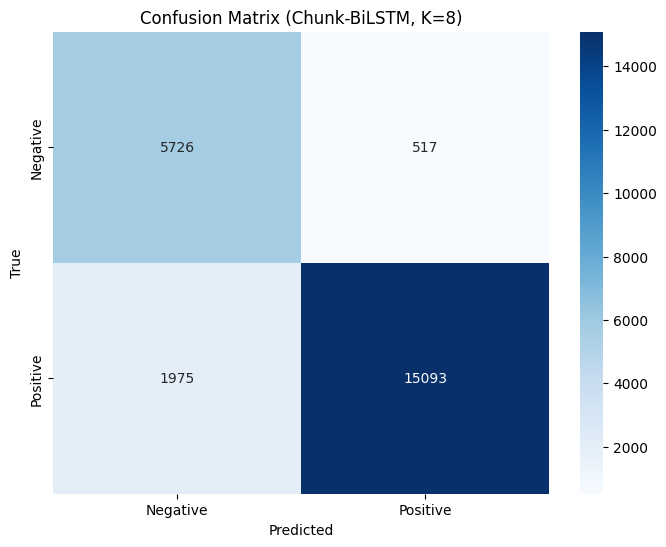

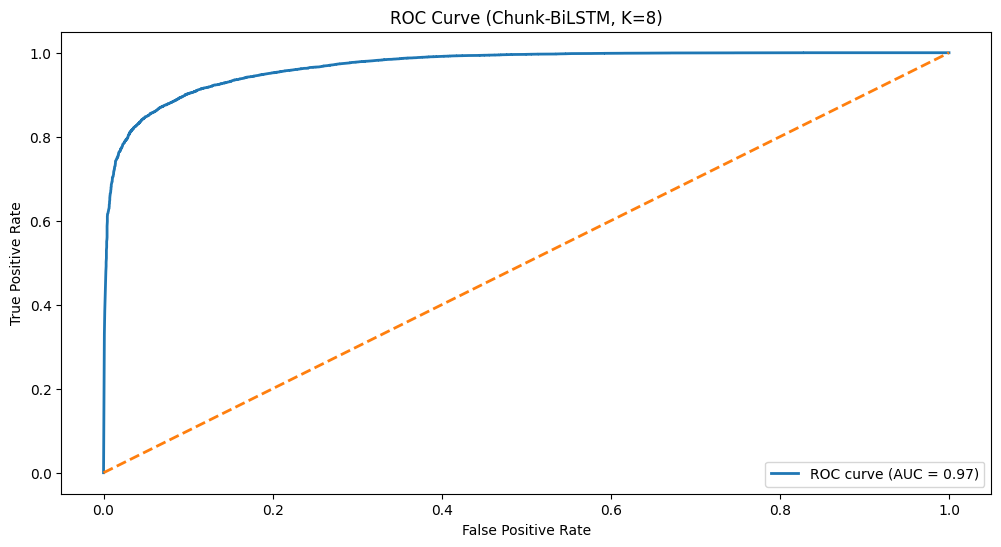

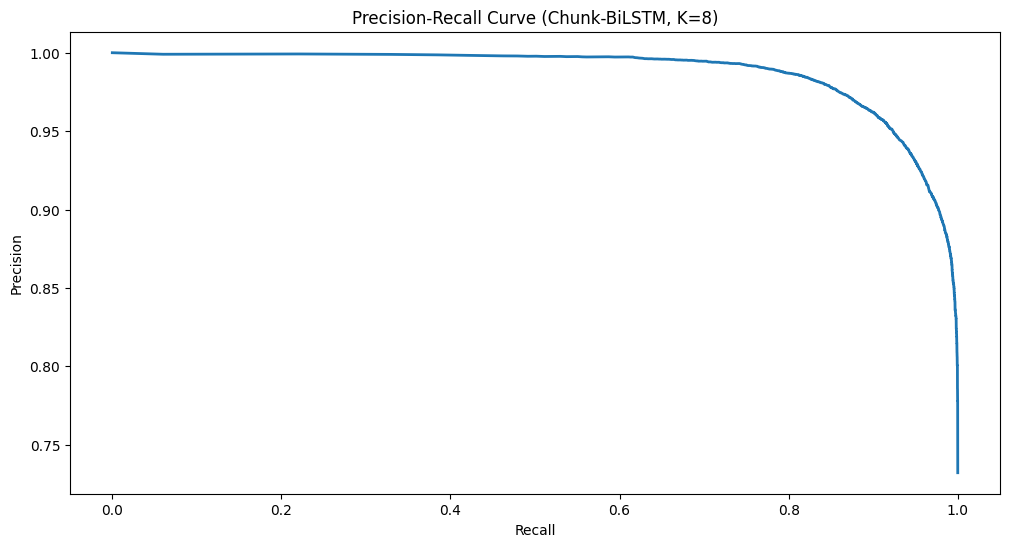

Saved test-set predictions to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/chunk_pooled/test_predictions_chunk_bilstm_K8.csv


In [ ]:
# =============================
# Cell 2/2: Train + evaluate BiLSTM on chunk-pooled features
# =============================
# - Loads chunk-pooled features (N, K, D)
# - Train/val/test split -> BiLSTM -> early stopping -> evaluation -> plots -> save predictions

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Reproducibility + device
# -----------------------------
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
print(f"Using device: {device} | AMP: {use_amp}")

# -----------------------------
# Load chunk-pooled features
# -----------------------------
K = 8  # MUST match the K used in Cell 1
chunk_dir = EMBED_DIR / "chunk_pooled"

features_path = chunk_dir / f"esm_chunkmean_K{K}.npy"
labels_path   = chunk_dir / "labels.npy"
meta_path     = chunk_dir / "sequence_metadata.csv"

print("Loading features from:", features_path)
X_chunk = np.load(features_path).astype(np.float32)  # (N, K, D)
y = np.load(labels_path).astype(np.int64)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X_chunk):
    raise ValueError("Metadata rows do not match features")

print("X_chunk shape:", X_chunk.shape, "(N, K, D)")
print(f"Label balance: pos={y.mean():.3f}, neg={1-y.mean():.3f}")

# -----------------------------
# Train/val/test split
# -----------------------------
indices = np.arange(len(y))
X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X_chunk, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1-y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1-y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1-y_test.mean():.3f}")

# -----------------------------
# Data loaders
# -----------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True, num_workers=2,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)

# -----------------------------
# Model: BiLSTM over K chunks
# -----------------------------
class ChunkBiLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=2, dropout_rate=0.3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)     # (B, K, 2H)
        out = out[:, -1, :]       # (B, 2H)
        out = self.bn(out)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits

D = X_chunk.shape[2]
model = ChunkBiLSTMClassifier(input_dim=D, hidden_dim=256, num_layers=2, dropout_rate=0.3).to(device)

# -----------------------------
# Loss with class weights
# -----------------------------
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# NEW AMP API (no warnings)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# -----------------------------
# Eval helper
# -----------------------------
@torch.no_grad()
def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        total_n += yb.size(0)

        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)

    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

# -----------------------------
# Train with early stopping
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
best_val_loss = float("inf")
early_stop_counter = 0

ckpt_dir = chunk_dir / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / f"best_chunk_bilstm_K{K}.pth"

print(f"Training Chunk-BiLSTM (K={K})...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}"
    )

    improved = (val_auc > best_val_auc + 1e-6) or (
        abs(val_auc - best_val_auc) <= 1e-6 and val_loss < best_val_loss - 1e-6
    )

    if improved:
        best_val_auc = val_auc
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)
acc = accuracy_score(y_true, y_pred)

print(f"\n=== Chunk-BiLSTM Results (K={K}) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Chunk-BiLSTM, K={K})")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Chunk-BiLSTM, K={K})")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Chunk-BiLSTM, K={K})")
plt.show()

# Save test predictions
pred_df = metadata_test.copy()
pred_df["y_true"] = y_true
pred_df["y_pred"] = y_pred
pred_df["y_prob_pos"] = y_prob

out_csv = chunk_dir / f"test_predictions_chunk_bilstm_K{K}.csv"
pred_df.to_csv(out_csv, index=False)
print("Saved test-set predictions to:", out_csv)


# Hybird

In [ ]:
# =============================
# 10-FOLD CROSS-VALIDATION: Hybrid BiLSTM -> CNN (1 embedding per sequence)
# - StratifiedKFold (10 folds)
# - Early stopping uses an inner validation split taken ONLY from training folds
# - Evaluates on the held-out fold (no leakage)
# - Reports per-fold + mean/std metrics
# - Saves out-of-fold predictions with original indices for metadata joins
# =============================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report

# -----------------------------
# Config
# -----------------------------
K_FOLDS = 10
random_seed = globals().get("random_seed", 42)

# training control
MAX_EPOCHS = 50
PATIENCE = 5
INNER_VAL_FRAC = 0.2  # split from training folds only (e.g., 20%)
VAL_BATCH = 512

# reproducibility
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Load embeddings + metadata
# -----------------------------
if "EMBED_DIR" not in globals():
    raise NameError("EMBED_DIR is not defined. Set EMBED_DIR = Path('...') in a setup cell.")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match X ({len(X)})")

N, D = X.shape
print(f"X: {X.shape}, y: {y.shape}")
print(f"Label balance: pos={y.mean():.3f}, neg={1-y.mean():.3f}")

# -----------------------------
# Model (Hybrid BiLSTM -> CNN), returns raw logits
# -----------------------------
class HybridBiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 lstm_dropout, conv_dropout,
                 c1=76, c2=111, c3=487):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.conv1 = nn.Conv2d(1, c1, kernel_size=(6, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=(4, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=(5, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(c3)

        self.dropout = nn.Dropout(conv_dropout)
        self.flatten_dim = self._infer_flatten_dim(2 * hidden_dim)
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def _infer_flatten_dim(self, feat_len: int) -> int:
        with torch.no_grad():
            x = torch.zeros(1, 1, feat_len, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            return x.view(1, -1).size(1)

    def forward(self, x):
        # x: (B, 1, D)
        B = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))        # (B, 1, 2H)
        out = out[:, -1, :]                    # (B, 2H)
        out = out.unsqueeze(1).unsqueeze(-1)   # (B, 1, 2H, 1)

        out = self.pool(F.relu(self.bn1(self.conv1(out))))
        out = self.pool(F.relu(self.bn2(self.conv2(out))))
        out = self.pool(F.relu(self.bn3(self.conv3(out))))

        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits  # raw logits

# -----------------------------
# Helpers
# -----------------------------
def compute_class_weights(y_arr: np.ndarray) -> torch.Tensor:
    n_pos = float((y_arr == 1).sum())
    n_neg = float((y_arr == 0).sum())
    w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
    w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
    return torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)

def make_loader(X_np, y_np, batch_size, shuffle):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=torch.cuda.is_available())

@torch.no_grad()
def eval_acc(model, loader) -> float:
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return correct / max(total, 1)

@torch.no_grad()
def eval_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1]
        probs_all.append(probs.detach().cpu().numpy())
        y_all.append(yb.numpy())
    return np.concatenate(y_all), np.concatenate(probs_all)

# -----------------------------
# Choose fixed hyperparams (plug in your best Optuna params here)
# -----------------------------
best_params = {
    "hidden_dim": 352,
    "num_layers": 1,
    "lstm_dropout": 0.5318422410383237,
    "conv_dropout": 0.15748478393244356,
    "lr": 0.000354186904235365,
    "weight_decay": 0.0025195878972576586,
    "batch_size": 16,
}

print("Using hyperparams:", best_params)

# reshape once: (N, 1, D)
X_seq = X.reshape(-1, 1, D)

# -----------------------------
# 10-fold CV
# -----------------------------
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=random_seed)

fold_metrics = []
oof_prob = np.zeros(N, dtype=np.float32)
oof_pred = np.zeros(N, dtype=np.int64)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(X_seq, y), start=1):
    # split trainval into train/inner-val
    X_trainval = X_seq[trainval_idx]
    y_trainval = y[trainval_idx]

    X_tr, X_va, y_tr, y_va = train_test_split(
        X_trainval, y_trainval,
        test_size=INNER_VAL_FRAC,
        stratify=y_trainval,
        random_state=random_seed
    )

    X_te = X_seq[test_idx]
    y_te = y[test_idx]

    # loaders
    train_loader = make_loader(X_tr, y_tr, batch_size=best_params["batch_size"], shuffle=True)
    val_loader   = make_loader(X_va, y_va, batch_size=VAL_BATCH, shuffle=False)
    test_loader  = make_loader(X_te, y_te, batch_size=VAL_BATCH, shuffle=False)

    # model
    model = HybridBiLSTM_CNN(
        input_dim=D,
        hidden_dim=best_params["hidden_dim"],
        num_layers=best_params["num_layers"],
        num_classes=2,
        lstm_dropout=best_params["lstm_dropout"],
        conv_dropout=best_params["conv_dropout"],
    ).to(device)

    # loss/optim
    cw = compute_class_weights(y_tr)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

    # train with early stopping on inner val acc
    best_val = -1.0
    patience_ctr = 0
    best_state = None

    print(f"\n===== Fold {fold}/{K_FOLDS} =====")
    print(f"Train={len(y_tr)} | Val={len(y_va)} | FoldTest={len(y_te)}")

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        val_acc = eval_acc(model, val_loader)
        if epoch == 1 or epoch % 5 == 0:
            print(f"Fold {fold} | Epoch {epoch:02d} | inner-val acc = {val_acc:.4f}")

        if val_acc > best_val + 1e-6:
            best_val = val_acc
            patience_ctr = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"Early stopping at epoch {epoch} (best inner-val acc={best_val:.4f})")
                break

    # load best state for fold evaluation
    if best_state is not None:
        model.load_state_dict(best_state)

    # evaluate on held-out fold
    y_true, y_prob = eval_probs(model, test_loader)
    y_hat = (y_prob >= 0.5).astype(np.int64)

    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    pr  = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")

    print(f"Fold {fold} results | Acc={acc:.4f} | ROC-AUC={auc:.4f} | PR-AUC={pr:.4f}")

    fold_metrics.append({"fold": fold, "acc": acc, "roc_auc": auc, "pr_auc": pr})

    # store OOF predictions aligned to original indices
    oof_prob[test_idx] = y_prob.astype(np.float32)
    oof_pred[test_idx] = y_hat.astype(np.int64)

# -----------------------------
# Summary
# -----------------------------
dfm = pd.DataFrame(fold_metrics)
print("\n===== 10-Fold CV Summary =====")
print(dfm)

def mean_std(x):
    return float(np.nanmean(x)), float(np.nanstd(x))

acc_mean, acc_std = mean_std(dfm["acc"].values)
auc_mean, auc_std = mean_std(dfm["roc_auc"].values)
pr_mean,  pr_std  = mean_std(dfm["pr_auc"].values)

print(f"\nAccuracy: {acc_mean:.4f} ± {acc_std:.4f}")
print(f"ROC-AUC : {auc_mean:.4f} ± {auc_std:.4f}")
print(f"PR-AUC  : {pr_mean:.4f} ± {pr_std:.4f}")

# -----------------------------
# Save out-of-fold predictions for later gene-level summary joins
# -----------------------------
oof_df = pd.DataFrame({
    "index": np.arange(N),
    "y_true": y.astype(np.int64),
    "y_pred": oof_pred.astype(np.int64),
    "y_prob_pos": oof_prob.astype(np.float32),
})
oof_out = EMBED_DIR / "oof_predictions_10fold_hybrid.csv"
oof_df.to_csv(oof_out, index=False)
print("\nSaved OOF predictions to:", oof_out)


Using device: cuda
Loading: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
X: (116555, 1280), y: (116555,)
Label balance: pos=0.732, neg=0.268
Using hyperparams: {'hidden_dim': 352, 'num_layers': 1, 'lstm_dropout': 0.5318422410383237, 'conv_dropout': 0.15748478393244356, 'lr': 0.000354186904235365, 'weight_decay': 0.0025195878972576586, 'batch_size': 16}

===== Fold 1/10 =====
Train=83919 | Val=20980 | FoldTest=11656
Fold 1 | Epoch 01 | inner-val acc = 0.8799
Fold 1 | Epoch 05 | inner-val acc = 0.8668
Fold 1 | Epoch 10 | inner-val acc = 0.9051
Early stopping at epoch 11 (best inner-val acc=0.9081)
Fold 1 results | Acc=0.9083 | ROC-AUC=0.9691 | PR-AUC=0.9886

===== Fold 2/10 =====
Train=83919 | Val=20980 | FoldTest=11656
Fold 2 | Epoch 01 | inner-val acc = 0.8883
Fold 2 | Epoch 05 | inner-val acc = 0.8990
Fold 2 | Epoch 10 | inner-val acc = 0.9035
Fold 2 | Epoch 15 | inner-val acc = 0.8969
Fold 2 | Epoch 20 | inner-val acc = 0.9017
Fold 2 | Epoch 25 | inner-val acc = 0.9

# Hybird Tuning

Using device: cuda
Loading embeddings from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/esm_features.npy
X shape: (116555, 1280) (N, D)


[I 2026-01-08 17:25:43,819] A new study created in memory with name: hybrid_bilstm_cnn_optuna_acc


Train size: 74595 | Val size: 18649 | Test size: 23311
Class balance (train): pos=0.732, neg=0.268
Class balance (val)  : pos=0.732, neg=0.268
Class balance (test) : pos=0.732, neg=0.268
Starting Optuna optimization (accuracy objective)...


  0%|          | 0/100 [00:00<?, ?it/s]

Trial 000 | epoch 01 | val_acc=0.8344
Trial 000 | epoch 05 | val_acc=0.8665
Trial 000 | epoch 10 | val_acc=0.8910
Trial 000 | epoch 15 | val_acc=0.8993
Trial 000 | epoch 20 | val_acc=0.8973
[I 2026-01-08 17:37:07,564] Trial 0 finished with value: 0.9010134591667114 and parameters: {'hidden_dim': 224, 'num_layers': 2, 'lstm_dropout': 0.5696939864886292, 'conv_dropout': 0.5640044598110543, 'lr': 4.6220254751911035e-05, 'weight_decay': 0.0001541042765745971, 'batch_size': 16}. Best is trial 0 with value: 0.9010134591667114.
[Optuna] Trial 000 COMPLETE | val_acc=0.901013 | params={'hidden_dim': 224, 'num_layers': 2, 'lstm_dropout': 0.5696939864886292, 'conv_dropout': 0.5640044598110543, 'lr': 4.6220254751911035e-05, 'weight_decay': 0.0001541042765745971, 'batch_size': 16}
Trial 001 | epoch 01 | val_acc=0.7695
Trial 001 | epoch 05 | val_acc=0.8924
Trial 001 | epoch 10 | val_acc=0.8962
Trial 001 | epoch 15 | val_acc=0.8764
[I 2026-01-08 17:41:54,155] Trial 1 finished with value: 0.9024076357

...

Final Epoch 56 | Val Acc 0.9945 | Val ROC-AUC 0.9999


Final Epoch 57 | Val Acc 0.9967 | Val ROC-AUC 1.0000
  Best model saved to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_hybrid_optuna_acc.pth


Final Epoch 58 | Val Acc 0.9962 | Val ROC-AUC 0.9999


Final Epoch 59 | Val Acc 0.9952 | Val ROC-AUC 0.9999


Final Epoch 60 | Val Acc 0.9948 | Val ROC-AUC 0.9999

Loading best final checkpoint: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_hybrid_optuna_acc.pth

=== Tuned Hybrid Results (Test) ===
Accuracy: 0.9119
ROC-AUC : 0.9632
PR-AUC  : 0.9831

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83      6243
    Positive       0.94      0.94      0.94     17068

    accuracy                           0.91     23311
   macro avg       0.89      0.88      0.89     23311
weighted avg       0.91      0.91      0.91     23311



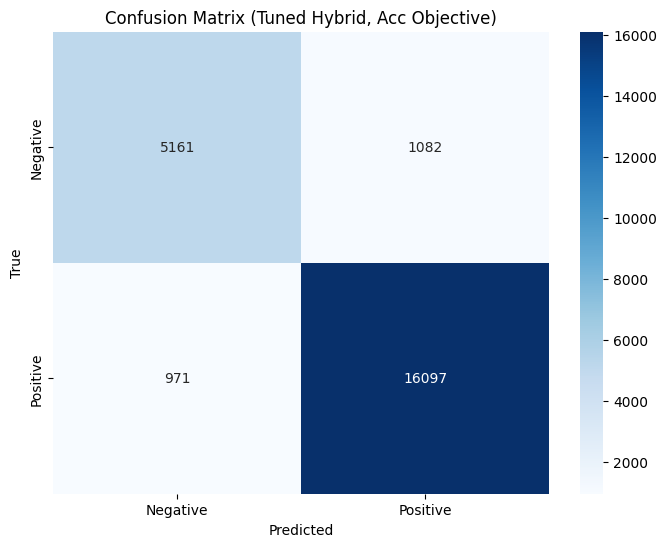

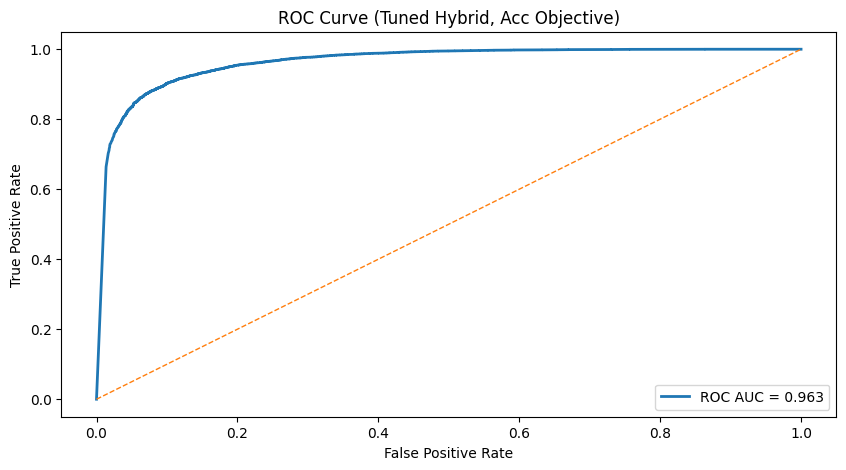

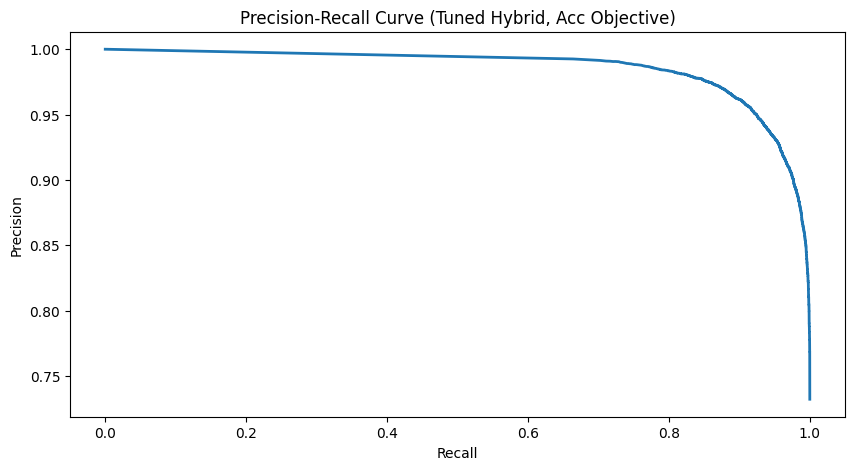

In [ ]:
# =============================
# COMPLETE CELL (ACCURACY-TUNED): Hybrid BiLSTM + CNN with Optuna tuning + visible progress
# - Tunes based on VALIDATION ACCURACY (instead of ROC-AUC)
# - Still uses a proper train/val/test split (no test leakage during tuning)
# - Model returns raw logits; CrossEntropyLoss is correct
# =============================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

import optuna

# -----------------------------
# Reproducibility
# -----------------------------
if "random_seed" not in globals():
    random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Load embeddings
# -----------------------------
if "EMBED_DIR" not in globals():
    raise NameError("EMBED_DIR is not defined. Please set EMBED_DIR = Path('...') in your setup cell.")

if not EMBED_DIR.exists():
    raise FileNotFoundError(f"Could not find directory at {EMBED_DIR}")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

print("Loading embeddings from:", features_path)
X = np.load(features_path).astype(np.float32)  # (N, D)
y = np.load(labels_path).astype(np.int64)      # (N,)
metadata = pd.read_csv(meta_path)

if len(metadata) != len(X):
    raise ValueError(f"Metadata rows ({len(metadata)}) do not match embeddings ({len(X)})")

N, D = X.shape
print(f"X shape: {X.shape} (N, D)")

# -----------------------------
# Train/val/test split (aligned indices)
# -----------------------------
indices = np.arange(len(y))

X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1-y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1-y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1-y_test.mean():.3f}")

# Reshape for LSTM input (T=1)
seq_len = 1
X_train_seq = X_train.reshape(-1, seq_len, D)
X_val_seq   = X_val.reshape(-1, seq_len, D)
X_test_seq  = X_test.reshape(-1, seq_len, D)

# -----------------------------
# Model: Hybrid BiLSTM -> CNN (raw logits)
# -----------------------------
class HybridBiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 lstm_dropout, conv_dropout,
                 c1=76, c2=111, c3=487):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.conv1 = nn.Conv2d(1, c1, kernel_size=(6, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=(4, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=(5, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(c3)

        self.dropout = nn.Dropout(conv_dropout)

        self.flatten_dim = self._get_flatten_dim(2 * hidden_dim)
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def _get_flatten_dim(self, feat_len: int) -> int:
        with torch.no_grad():
            x = torch.zeros(1, 1, feat_len, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            x = x.view(1, -1)
            return x.size(1)

    def forward(self, x):
        B = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))   # (B, 1, 2H)
        out = out[:, -1, :]               # (B, 2H)
        out = out.unsqueeze(1).unsqueeze(-1)  # (B, 1, 2H, 1)

        out = self.pool(F.relu(self.bn1(self.conv1(out))))
        out = self.pool(F.relu(self.bn2(self.conv2(out))))
        out = self.pool(F.relu(self.bn3(self.conv3(out))))

        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits  # raw logits

# -----------------------------
# Helpers
# -----------------------------
def class_weights(y_arr):
    n_pos = float((y_arr == 1).sum())
    n_neg = float((y_arr == 0).sum())
    w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
    w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
    return torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)

def make_loaders(Xtr, ytr, Xva, yva, batch_size):
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        TensorDataset(Xva_t, yva_t),
        batch_size=max(256, batch_size), shuffle=False,
        num_workers=2, pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader

def eval_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / max(total, 1)

def eval_probs(model, loader):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
    return np.concatenate(all_true), np.concatenate(all_probs)

# -----------------------------
# Optuna setup: show tuning progress
# -----------------------------
optuna.logging.set_verbosity(optuna.logging.INFO)

def print_trial_callback(study, trial):
    status = trial.state.name
    value_str = f"{trial.value:.6f}" if trial.value is not None else "None"
    print(f"[Optuna] Trial {trial.number:03d} {status} | val_acc={value_str} | params={trial.params}")

# -----------------------------
# Objective: maximize validation ACCURACY
# -----------------------------
def objective(trial: optuna.Trial) -> float:
    hidden_dim = trial.suggest_int("hidden_dim", 64, 384, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    lstm_dropout = trial.suggest_float("lstm_dropout", 0.0, 0.6)
    conv_dropout = trial.suggest_float("conv_dropout", 0.0, 0.7)

    lr = trial.suggest_float("lr", 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    model = HybridBiLSTM_CNN(
        input_dim=D,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=2,
        lstm_dropout=lstm_dropout,
        conv_dropout=conv_dropout,
    ).to(device)

    train_loader, val_loader = make_loaders(X_train_seq, y_train, X_val_seq, y_val, batch_size)

    cw = class_weights(y_train)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    n_epochs = 40
    patience = 5
    best_val_acc = -1.0
    early_stop = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        val_acc = eval_acc(model, val_loader)

        # visible epoch prints
        if epoch == 1 or epoch % 5 == 0:
            print(f"Trial {trial.number:03d} | epoch {epoch:02d} | val_acc={val_acc:.4f}")

        trial.report(val_acc, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            early_stop = 0
        else:
            early_stop += 1
            if early_stop >= patience:
                break

    return best_val_acc

# -----------------------------
# Run Optuna tuning
# -----------------------------
study = optuna.create_study(
    direction="maximize",
    study_name="hybrid_bilstm_cnn_optuna_acc",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

print("Starting Optuna optimization (accuracy objective)...")
study.optimize(
    objective,
    n_trials=100,                 # increase for better tuning (e.g., 80-150)
    callbacks=[print_trial_callback],
    show_progress_bar=True
)

print("\nOptuna finished.")
print("Best value (val accuracy):", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params

# -----------------------------
# Train final model on train+val, evaluate once on test
# -----------------------------
X_trainval = np.concatenate([X_train_seq, X_val_seq], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

final_batch_size = best_params["batch_size"]

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_trainval, dtype=torch.float32), torch.tensor(y_trainval, dtype=torch.long)),
    batch_size=final_batch_size, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader_for_earlystop = DataLoader(
    TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
    batch_size=max(256, final_batch_size), shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)),
    batch_size=max(256, final_batch_size), shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

final_model = HybridBiLSTM_CNN(
    input_dim=D,
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    num_classes=2,
    lstm_dropout=best_params["lstm_dropout"],
    conv_dropout=best_params["conv_dropout"],
).to(device)

cw = class_weights(y_trainval)
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

n_epochs = 60
patience = 8
best_val_acc = -1.0
early_stop = 0

ckpt_dir = EMBED_DIR / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_file = ckpt_dir / "best_hybrid_optuna_acc.pth"

print("\nTraining final tuned model (early stop on val accuracy)...")
for epoch in range(1, n_epochs + 1):
    final_model.train()
    for xb, yb in tqdm(train_loader, desc=f"Final Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = final_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    val_acc = eval_acc(final_model, val_loader_for_earlystop)
    y_true_val, y_prob_val = eval_probs(final_model, val_loader_for_earlystop)
    val_auc = roc_auc_score(y_true_val, y_prob_val) if len(np.unique(y_true_val)) == 2 else 0.5

    print(f"Final Epoch {epoch:02d} | Val Acc {val_acc:.4f} | Val ROC-AUC {val_auc:.4f}")

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        early_stop = 0
        torch.save(final_model.state_dict(), ckpt_file)
        print(f"  Best model saved to: {ckpt_file}")
    else:
        early_stop += 1
        if early_stop >= patience:
            print("Early stopping triggered")
            break

print("\nLoading best final checkpoint:", ckpt_file)
final_model.load_state_dict(torch.load(ckpt_file, map_location=device))

# -----------------------------
# Test evaluation
# -----------------------------
y_true_test, y_prob_test = eval_probs(final_model, test_loader)
y_pred_test = (y_prob_test >= 0.5).astype(np.int64)

test_acc = accuracy_score(y_true_test, y_pred_test)
test_auc = roc_auc_score(y_true_test, y_prob_test) if len(np.unique(y_true_test)) == 2 else float("nan")
test_pr  = average_precision_score(y_true_test, y_prob_test) if len(np.unique(y_true_test)) == 2 else float("nan")

print("\n=== Tuned Hybrid Results (Test) ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"ROC-AUC : {test_auc:.4f}")
print(f"PR-AUC  : {test_pr:.4f}\n")
print(classification_report(y_true_test, y_pred_test, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Tuned Hybrid, Acc Objective)")
plt.show()

fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tuned Hybrid, Acc Objective)")
plt.legend(loc="lower right")
plt.show()

precision, recall, _ = precision_recall_curve(y_true_test, y_prob_test)
plt.figure(figsize=(10, 5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Tuned Hybrid, Acc Objective)")
plt.show()


In [ ]:
# =============================
# FINAL TRAINING — OPTION A (FULLY STANDALONE)
# Train on TRAIN, early stop on VAL, evaluate once on TEST
# Uses fixed Optuna-selected hyperparameters
# =============================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIG
# -----------------------------
random_seed = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MUST be defined already
# EMBED_DIR = Path("...")

features_path = EMBED_DIR / "esm_features.npy"
labels_path   = EMBED_DIR / "labels.npy"
meta_path     = EMBED_DIR / "sequence_metadata.csv"

# -----------------------------
# Best hyperparameters (from Optuna)
# -----------------------------
best_params = {
    "hidden_dim": 352,
    "num_layers": 1,
    "lstm_dropout": 0.5318422410383237,
    "conv_dropout": 0.15748478393244356,
    "lr": 0.000354186904235365,
    "weight_decay": 0.0025195878972576586,
    "batch_size": 16,
}

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

# -----------------------------
# Load data
# -----------------------------
X = np.load(features_path).astype(np.float32)   # (N, D)
y = np.load(labels_path).astype(np.int64)
metadata = pd.read_csv(meta_path)

N, D = X.shape
print(f"Loaded X: {X.shape}, y: {y.shape}")

# -----------------------------
# Train / Val / Test split (64 / 16 / 20)
# -----------------------------
indices = np.arange(len(y))

X_tmp, X_test, y_tmp, y_test, idx_tmp, idx_test = train_test_split(
    X, y, indices,
    test_size=0.20,
    stratify=y,
    random_state=random_seed
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=0.20,
    stratify=y_tmp,
    random_state=random_seed
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# -----------------------------
# Reshape for BiLSTM input (T = 1)
# -----------------------------
seq_len = 1
X_train_seq = X_train.reshape(-1, seq_len, D)
X_val_seq   = X_val.reshape(-1, seq_len, D)
X_test_seq  = X_test.reshape(-1, seq_len, D)

# -----------------------------
# Model definition
# -----------------------------
class HybridBiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 lstm_dropout, conv_dropout,
                 c1=76, c2=111, c3=487):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.conv1 = nn.Conv2d(1, c1, kernel_size=(6, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool = nn.MaxPool2d((2, 1))

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=(4, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=(5, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(c3)

        self.dropout = nn.Dropout(conv_dropout)
        self.flatten_dim = self._get_flatten_dim(2 * hidden_dim)
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def _get_flatten_dim(self, feat_len):
        with torch.no_grad():
            x = torch.zeros(1, 1, feat_len, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            return x.view(1, -1).size(1)

    def forward(self, x):
        B = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = out.unsqueeze(1).unsqueeze(-1)

        out = self.pool(F.relu(self.bn1(self.conv1(out))))
        out = self.pool(F.relu(self.bn2(self.conv2(out))))
        out = self.pool(F.relu(self.bn3(self.conv3(out))))

        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        return self.fc(out)

# -----------------------------
# DataLoaders
# -----------------------------
batch_size = best_params["batch_size"]

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_seq), torch.tensor(y_train)),
    batch_size=batch_size, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_seq), torch.tensor(y_val)),
    batch_size=256, shuffle=False
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_seq), torch.tensor(y_test)),
    batch_size=256, shuffle=False
)

# -----------------------------
# Class weights
# -----------------------------
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
class_weights = torch.tensor(
    [(n_pos + n_neg) / (2 * n_neg), (n_pos + n_neg) / (2 * n_pos)],
    dtype=torch.float32,
    device=device
)

# -----------------------------
# Train (early stop on VAL)
# -----------------------------
model = HybridBiLSTM_CNN(
    D,
    best_params["hidden_dim"],
    best_params["num_layers"],
    2,
    best_params["lstm_dropout"],
    best_params["conv_dropout"]
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

best_val_acc = -1.0
patience = 8
counter = 0

ckpt_path = EMBED_DIR / "model_checkpoints" / "best_hybrid_optionA.pth"
ckpt_path.parent.mkdir(exist_ok=True)

print("\nTraining final model (Option A)...")
for epoch in range(1, 61):
    model.train()
    for xb, yb in tqdm(train_loader, leave=False):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch:02d} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# -----------------------------
# Test evaluation (ONCE)
# -----------------------------
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

all_logits, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_logits.append(model(xb).cpu())
        all_true.append(yb)

all_logits = torch.cat(all_logits).numpy()
all_true = torch.cat(all_true).numpy()
y_pred = all_logits.argmax(1)

print("\n=== FINAL TEST RESULTS ===")
print("Accuracy:", accuracy_score(all_true, y_pred))
print("ROC-AUC :", roc_auc_score(all_true, all_logits[:, 1]))
print("PR-AUC  :", average_precision_score(all_true, all_logits[:, 1]))
print(classification_report(all_true, y_pred, target_names=["Negative", "Positive"]))


Using device: cuda
Loaded X: (116555, 1280), y: (116555,)
Train: 74595 | Val: 18649 | Test: 23311

Training final model (Option A)...


Epoch 01 | Val Acc: 0.8760


Epoch 02 | Val Acc: 0.8907


Epoch 03 | Val Acc: 0.8551


Epoch 04 | Val Acc: 0.9013


...

Epoch 18 | Val Acc: 0.9032


Epoch 19 | Val Acc: 0.8980


Epoch 20 | Val Acc: 0.8998


Epoch 21 | Val Acc: 0.9036


Epoch 22 | Val Acc: 0.9059
Early stopping

=== FINAL TEST RESULTS ===
Accuracy: 0.9092703015743641
ROC-AUC : 0.9663194092124214
PR-AUC  : 0.9874053456982829
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83      6243
    Positive       0.94      0.94      0.94     17068

    accuracy                           0.91     23311
   macro avg       0.88      0.88      0.88     23311
weighted avg       0.91      0.91      0.91     23311



# Gene-Level

In [ ]:
# =============================
# LOAD FINAL TRAINED MODEL (Option A)
# =============================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Model definition (MUST MATCH training exactly)
# -----------------------------
class HybridBiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 lstm_dropout, conv_dropout,
                 c1=76, c2=111, c3=487):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.conv1 = nn.Conv2d(1, c1, kernel_size=(6, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool = nn.MaxPool2d((2, 1))

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=(4, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=(5, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(c3)

        self.dropout = nn.Dropout(conv_dropout)
        self.flatten_dim = self._get_flatten_dim(2 * hidden_dim)
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def _get_flatten_dim(self, feat_len):
        with torch.no_grad():
            x = torch.zeros(1, 1, feat_len, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            return x.view(1, -1).size(1)

    def forward(self, x):
        B = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = out.unsqueeze(1).unsqueeze(-1)

        out = self.pool(F.relu(self.bn1(self.conv1(out))))
        out = self.pool(F.relu(self.bn2(self.conv2(out))))
        out = self.pool(F.relu(self.bn3(self.conv3(out))))

        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        return self.fc(out)

# -----------------------------
# Best hyperparameters (from Optuna)
# -----------------------------
best_params = {
    "hidden_dim": 352,
    "num_layers": 1,
    "lstm_dropout": 0.5318422410383237,
    "conv_dropout": 0.15748478393244356,
}

# -----------------------------
# Load data to get input dimension
# -----------------------------
X = np.load(EMBED_DIR / "esm_features.npy").astype(np.float32)
D = X.shape[1]

# -----------------------------
# Build model and load weights
# -----------------------------
model = HybridBiLSTM_CNN(
    input_dim=D,
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    num_classes=2,
    lstm_dropout=best_params["lstm_dropout"],
    conv_dropout=best_params["conv_dropout"],
).to(device)

ckpt_path = EMBED_DIR / "model_checkpoints" / "best_hybrid_optionA.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

print("Model loaded from:", ckpt_path)

# Load full metadata
meta_path = EMBED_DIR / "sequence_metadata.csv"
metadata_all = pd.read_csv(meta_path)

# Load X, y (must be in the same original order as used in training)
X = np.load(EMBED_DIR / "esm_features.npy").astype(np.float32)
y = np.load(EMBED_DIR / "labels.npy").astype(np.int64)

indices = np.arange(len(y))

# Recreate the SAME split you used
_, X_test, _, y_test_np, _, idx_test = train_test_split(
    X, y, indices,
    test_size=0.20,
    stratify=y,
    random_state=random_seed
)

# IMPORTANT: you must also reshape X_test the same way you did when evaluating
seq_len = 1
D = X.shape[1]
X_test_seq = X_test.reshape(-1, seq_len, D)

# metadata_test
metadata_test = metadata_all.iloc[idx_test].reset_index(drop=True)

# --- inference + gene summary (same as Option 1) ---
model.eval()

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.long)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_true.append(yb.cpu().numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

df_seq = metadata_test.copy()
df_seq["y_true"] = y_true
df_seq["y_pred"] = y_pred
df_seq["correct"] = (df_seq["y_true"] == df_seq["y_pred"]).astype(int)
df_seq["gene"] = df_seq["gene"].str.split("_AND_", n=1).str[0]


gene_summary = (
    df_seq.groupby("gene", dropna=False)
    .agg(n_sequences=("correct", "count"), n_correct=("correct", "sum"))
    .reset_index()
)
gene_summary["accuracy"] = gene_summary["n_correct"] / gene_summary["n_sequences"]
gene_summary = gene_summary.sort_values(["accuracy", "n_sequences"], ascending=[False, False]).reset_index(drop=True)

out_path = EMBED_DIR / "gene_level_accuracy_summary_testset.csv"
gene_summary.to_csv(out_path, index=False)
print("Saved gene-level summary to:", out_path)
display(gene_summary.head(20))


Using device: cuda
Model loaded from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_hybrid_optionA.pth
Saved gene-level summary to: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/gene_level_accuracy_summary_testset.csv


,gene,n_sequences,n_correct,accuracy
0,RPL6,83,83,1.0
1,YAP1,41,41,1.0
2,NOX1,29,29,1.0
3,ULK1,25,25,1.0
4,NOX4,22,22,1.0
5,QSOX1,17,17,1.0
6,ALOX5,15,15,1.0
7,AQP3,13,13,1.0
8,AQP8,13,13,1.0
9,HMGB1,13,13,1.0


Using device: cuda
Loaded model from: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/model_checkpoints/best_hybrid_optionA.pth
High-confidence sequences: 19647 / 23311

=== HIGH-CONFIDENCE SEQUENCE RESULTS ===
Accuracy: 0.9617244363007075
ROC-AUC : 0.9836567272090344
PR-AUC  : 0.9947536200490754
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.91      4443
    Positive       0.97      0.98      0.98     15204

    accuracy                           0.96     19647
   macro avg       0.95      0.94      0.94     19647
weighted avg       0.96      0.96      0.96     19647



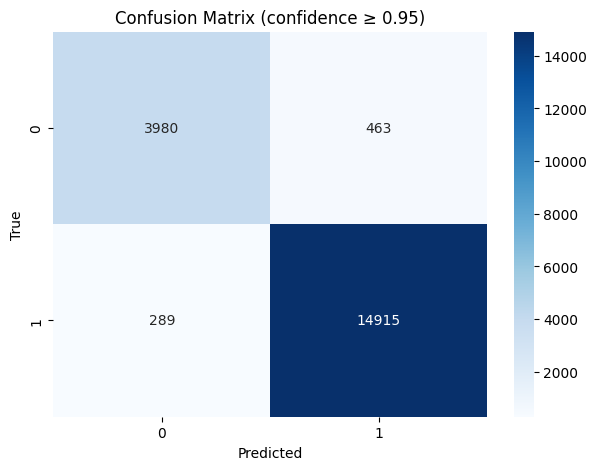

Saved: /content/drive/MyDrive/JR_Ferro/ESM_Embedding/test_high_confidence_sequences_0.95.csv


,sequence_id,label,source,gene,entry,file,idx,header,sequence_length,y_true,y_pred,p_pos,p_max
0,59812,1,pos_ferro,CFL1_AND_database_facet_100_2025_12_26,UPI0007397DA2,uniparc_CFL1_AND_database_facet_100_2025_12_26,1879,pos_ferro|gene=CFL1_AND_database_facet_100_202...,392,1,1,0.994058,0.994058
1,36265,1,pos_ferro,POR_AND_database_facet_100_2025_12_26,UPI0002716B23,uniparc_POR_AND_database_facet_100_2025_12_26,1985,pos_ferro|gene=POR_AND_database_facet_100_2025...,266,1,1,1.000000,1.000000
2,101583,0,neg_ferro,ANAPC5,UPI0007DFAEF7,uniparc_ANAPC5,747,neg_ferro|gene=ANAPC5|entry=UPI0007DFAEF7|file...,40,0,0,0.032061,0.967939
3,114145,1,pos_ferro,SAT1_AND_database_facet_100_2025_12_26,UPI0007DDE635,uniparc_SAT1_AND_database_facet_100_2025_12_26,5504,pos_ferro|gene=SAT1_AND_database_facet_100_202...,791,1,1,1.000000,1.000000
4,26249,1,pos_ferro,ABCC1_AND_database_facet_100_2025_12_26,UPI0019E36B20,uniparc_ABCC1_AND_database_facet_100_2025_12_26,1965,pos_ferro|gene=ABCC1_AND_database_facet_100_20...,1446,1,1,0.988878,0.988878
5,11405,1,pos_ferro,TF_AND_database_facet_100_2025_12_26,UPI002B56307D,uniparc_TF_AND_database_facet_100_2025_12_26,28045,pos_ferro|gene=TF_AND_database_facet_100_2025_...,343,1,1,1.000000,1.000000
6,97397,1,pos_ferro,SCP2_AND_database_facet_100_2025_12_26,UPI000EA3D114,uniparc_SCP2_AND_database_facet_100_2025_12_26,17899,pos_ferro|gene=SCP2_AND_database_facet_100_202...,220,1,1,0.999961,0.999961
7,102746,1,pos_ferro,ATM_AND_database_facet_100_2025_12_26,UPI000EBB0AC0,uniparc_ATM_AND_database_facet_100_2025_12_26,7304,pos_ferro|gene=ATM_AND_database_facet_100_2025...,105,1,1,0.999918,0.999918
8,47688,0,neg_ferro,BUB3,UPI00263C1232,uniparc_BUB3_,3560,neg_ferro|gene=BUB3|entry=UPI00263C1232|file=u...,339,0,0,0.000462,0.999538
9,92382,0,neg_ferro,RDX,UPI001E15E257,uniparc_RDX,2559,neg_ferro|gene=RDX|entry=UPI001E15E257|file=un...,462,0,0,0.023042,0.976958


In [ ]:
# =============================
# STANDALONE CELL
# High-confidence SEQUENCE evaluation on 20% TEST SET
# Confidence = max softmax prob >= 0.95
# =============================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIG
# -----------------------------
random_seed = 42
conf_threshold = 0.95
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# EMBED_DIR must already exist
# EMBED_DIR = Path("...")

# -----------------------------
# Model definition (MUST MATCH TRAINING)
# -----------------------------
class HybridBiLSTM_CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 lstm_dropout, conv_dropout,
                 c1=76, c2=111, c3=487):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.conv1 = nn.Conv2d(1, c1, kernel_size=(6, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool = nn.MaxPool2d((2, 1))

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=(4, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=(5, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(c3)

        self.dropout = nn.Dropout(conv_dropout)
        self.flatten_dim = self._get_flatten_dim(2 * hidden_dim)
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def _get_flatten_dim(self, feat_len):
        with torch.no_grad():
            x = torch.zeros(1, 1, feat_len, 1)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            return x.view(1, -1).size(1)

    def forward(self, x):
        B = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, B, self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = out.unsqueeze(1).unsqueeze(-1)

        out = self.pool(F.relu(self.bn1(self.conv1(out))))
        out = self.pool(F.relu(self.bn2(self.conv2(out))))
        out = self.pool(F.relu(self.bn3(self.conv3(out))))

        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        return self.fc(out)

# -----------------------------
# Load data
# -----------------------------
X = np.load(EMBED_DIR / "esm_features.npy").astype(np.float32)
y = np.load(EMBED_DIR / "labels.npy").astype(np.int64)
metadata_all = pd.read_csv(EMBED_DIR / "sequence_metadata.csv")

N, D = X.shape

# -----------------------------
# Recreate SAME test split
# -----------------------------
indices = np.arange(len(y))
_, X_test, _, y_test, _, idx_test = train_test_split(
    X, y, indices,
    test_size=0.20,
    stratify=y,
    random_state=random_seed
)

metadata_test = metadata_all.iloc[idx_test].reset_index(drop=True)

# -----------------------------
# Load trained model
# -----------------------------
best_params = {
    "hidden_dim": 352,
    "num_layers": 1,
    "lstm_dropout": 0.5318422410383237,
    "conv_dropout": 0.15748478393244356,
}

model = HybridBiLSTM_CNN(
    input_dim=D,
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    num_classes=2,
    lstm_dropout=best_params["lstm_dropout"],
    conv_dropout=best_params["conv_dropout"],
).to(device)

ckpt_path = EMBED_DIR / "model_checkpoints" / "best_hybrid_optionA.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

print("Loaded model from:", ckpt_path)

# -----------------------------
# Inference on full test set
# -----------------------------
seq_len = 1
X_test_seq = X_test.reshape(-1, seq_len, D)

loader = DataLoader(
    TensorDataset(torch.tensor(X_test_seq), torch.tensor(y_test)),
    batch_size=256, shuffle=False
)

all_logits = []
all_true = []
with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb).cpu()
        all_logits.append(logits)
        all_true.append(yb)

all_logits = torch.cat(all_logits).numpy()
all_true = torch.cat(all_true).numpy()

probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()
p_pos = probs[:, 1]
p_max = probs.max(axis=1)
y_pred = probs.argmax(axis=1)

# -----------------------------
# High-confidence filtering
# -----------------------------
mask = p_max >= conf_threshold

print(f"High-confidence sequences: {mask.sum()} / {len(mask)}")

true_sub = all_true[mask]
pred_sub = y_pred[mask]
p_pos_sub = p_pos[mask]
meta_sub = metadata_test.loc[mask].reset_index(drop=True)

# -----------------------------
# Metrics
# -----------------------------
print("\n=== HIGH-CONFIDENCE SEQUENCE RESULTS ===")
print("Accuracy:", accuracy_score(true_sub, pred_sub))

if len(np.unique(true_sub)) == 2:
    print("ROC-AUC :", roc_auc_score(true_sub, p_pos_sub))
    print("PR-AUC  :", average_precision_score(true_sub, p_pos_sub))

print(classification_report(true_sub, pred_sub, target_names=["Negative", "Positive"]))

cm = confusion_matrix(true_sub, pred_sub)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (confidence ≥ {conf_threshold})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# Save subset
# -----------------------------
out_df = meta_sub.copy()
out_df["y_true"] = true_sub
out_df["y_pred"] = pred_sub
out_df["p_pos"] = p_pos_sub
out_df["p_max"] = p_max[mask]

out_path = EMBED_DIR / f"test_high_confidence_sequences_{conf_threshold:.2f}.csv"
out_df.to_csv(out_path, index=False)
print("Saved:", out_path)

display(out_df.head(10))


# Per

In [ ]:
# Chunk-pooled ESM embeddings + BiLSTM classifier
# - Same style as LR/XGBoost cells: load -> (optional build features) -> split -> train (early stop) -> evaluate -> plot -> save
# - Uses GPU automatically (A100). Uses AMP (mixed precision) on CUDA for speed.
# - Representation: split each ESM token embedding sequence into K segments, mean-pool each segment -> (K, D)
#   Then feed as a true sequence to BiLSTM (seq_len = K).
#
# Requirements:
#   - You must already have sequence_df with columns: ["sequence_id", "sequence", "label"] in memory
#   - You must have ESM installed and a GPU runtime (recommended)
#   - Set EMBED_DIR to your Google Drive folder for outputs (where you want to save the chunk-pooled features)

import os
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import esm

# -----------------------------
# Reproducibility + device
# -----------------------------
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
print(f"Using device: {device} | AMP: {use_amp}")

# -----------------------------
# Output paths
# -----------------------------
# Example:
# EMBED_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding")
chunk_dir = EMBED_DIR / "chunk_pooled"
chunk_dir.mkdir(parents=True, exist_ok=True)

# Feature artifact names
K = 8  # number of segments (set to 4 or 8)
ESM_MODEL = "esm2_t33_650M_UR50D"
MAX_SEQUENCES_PER_BATCH = 8
MAX_TOKENS_PER_BATCH = 2000
MAX_RESIDUES_PER_CHUNK = 1000  # for splitting very long proteins (compute-time safety)

features_path = chunk_dir / f"esm_chunkmean_K{K}.npy"
labels_path   = chunk_dir / "labels.npy"
meta_path     = chunk_dir / "sequence_metadata.csv"

# -----------------------------
# Helper: batching over raw sequences (tokenization happens inside ESM batch_converter)
# -----------------------------
def chunked_rows(df: pd.DataFrame):
    """
    Yields (row, chunk_seq, chunk_id).
    This is ONLY for compute-time safety on very long sequences.
    We will pool *within* each chunk to K segments; if a sequence was split into multiple chunks,
    we will average the resulting (K, D) across chunks.
    """
    for row in df.itertuples():
        seq = row.sequence
        if len(seq) <= MAX_RESIDUES_PER_CHUNK:
            yield row, seq, 0
        else:
            cid = 0
            for start in range(0, len(seq), MAX_RESIDUES_PER_CHUNK):
                yield row, seq[start:start + MAX_RESIDUES_PER_CHUNK], cid
                cid += 1

def batch_iter(df: pd.DataFrame):
    batch_items = []
    token_budget = 0
    for row, seq, cid in chunked_rows(df):
        length = len(seq) + 2  # BOS/EOS
        if batch_items and (len(batch_items) >= MAX_SEQUENCES_PER_BATCH or token_budget + length > MAX_TOKENS_PER_BATCH):
            yield batch_items
            batch_items = []
            token_budget = 0
        batch_items.append((row, seq, cid))
        token_budget += length
    if batch_items:
        yield batch_items

# -----------------------------
# Chunk-mean pooling to K segments
# -----------------------------
def segment_mean_pool(token_reps: torch.Tensor, K: int) -> torch.Tensor:
    """
    token_reps: (L, D) per-residue embeddings (already without BOS/EOS)
    returns: (K, D) where each segment is mean pooled
    Handles short sequences by allowing empty segments (we clamp to at least 1 residue per segment).
    """
    L, D = token_reps.shape
    # Compute segment boundaries
    # We use approximately equal-size segments; last segment takes the remainder.
    # Ensure each segment has at least 1 residue by using integer boundaries carefully.
    boundaries = torch.linspace(0, L, steps=K + 1, device=token_reps.device)
    boundaries = boundaries.round().long()
    boundaries[0] = 0
    boundaries[-1] = L

    pooled = []
    for i in range(K):
        s = int(boundaries[i].item())
        e = int(boundaries[i + 1].item())
        if e <= s:
            # fallback: take one residue (clamp)
            s = min(s, L - 1)
            e = min(s + 1, L)
        pooled.append(token_reps[s:e].mean(dim=0))
    return torch.stack(pooled, dim=0)  # (K, D)

# -----------------------------
# Build (or load) chunk-pooled features: X_chunk has shape (N, K, D)
# -----------------------------
def build_chunk_pooled_features(sequence_df: pd.DataFrame, K: int) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    # Load ESM
    model_loader = getattr(esm.pretrained, ESM_MODEL)
    model, alphabet = model_loader()
    model = model.eval().to(device)
    repr_layer = model.num_layers
    batch_converter = alphabet.get_batch_converter()

    # Allow TF32 for speed on A100 (safe for inference/feature extraction)
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    N = len(sequence_df)
    D = model.embed_dim

    # Accumulate per-seq pooled (K, D). If a sequence was split into multiple chunks,
    # we average pooled chunks.
    X_accum = np.zeros((N, K, D), dtype=np.float32)
    counts = np.zeros((N,), dtype=np.int32)

    processed = 0
    for batch_items in batch_iter(sequence_df):
        batch_ids = [str(item[0].sequence_id) for item in batch_items]
        batch_seqs = [item[1] for item in batch_items]
        batch_data = list(zip(batch_ids, batch_seqs))

        _, _, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device, non_blocking=True)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)

        token_reps = results["representations"][repr_layer]  # (B, T, D)
        # Remove BOS/EOS
        token_reps = token_reps[:, 1:-1, :]  # (B, L, D)

        for i, (row, seq, cid) in enumerate(batch_items):
            reps_i = token_reps[i]              # (L, D)
            pooled_i = segment_mean_pool(reps_i, K)  # (K, D)
            idx = row.Index
            X_accum[idx] += pooled_i.detach().cpu().numpy()
            counts[idx] += 1

        processed += len(batch_items)
        if processed % 200 == 0:
            print(f"Processed {processed} chunks")

    if np.any(counts == 0):
        missing = np.where(counts == 0)[0][:10]
        raise RuntimeError(f"Missing features for {len(missing)} sequences (example idx: {missing})")

    X_accum /= counts[:, None, None]

    y = sequence_df["label"].to_numpy(dtype=np.int64)
    metadata_cols = [c for c in sequence_df.columns if c != "sequence"]
    metadata = sequence_df[metadata_cols].copy()

    return X_accum, y, metadata

# Build once (or load if already computed)
if features_path.exists() and labels_path.exists() and meta_path.exists():
    print("Loading chunk-pooled features from:", features_path)
    X_chunk = np.load(features_path).astype(np.float32)  # (N, K, D)
    y = np.load(labels_path).astype(np.int64)
    metadata = pd.read_csv(meta_path)
    if len(metadata) != len(X_chunk):
        raise ValueError("Metadata rows do not match features")
else:
    print(f"Building chunk-pooled features (K={K}) with ESM...")
    X_chunk, y, metadata = build_chunk_pooled_features(sequence_df, K=K)

    np.save(features_path, X_chunk.astype(np.float32))
    np.save(labels_path, y.astype(np.int64))
    metadata.to_csv(meta_path, index=False)

    print("Saved chunk-pooled features to:", features_path)
    print("Saved labels to:", labels_path)
    print("Saved metadata to:", meta_path)

print(f"X_chunk shape: {X_chunk.shape} (N, K, D)")
print(f"Label balance: pos={y.mean():.3f}, neg={1-y.mean():.3f}")

# -----------------------------
# Train/val/test split
# -----------------------------
indices = np.arange(len(y))
X_train_temp, X_test, y_train_temp, y_test, idx_train_temp, idx_test = train_test_split(
    X_chunk, y, indices, test_size=0.2, stratify=y, random_state=random_seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp, random_state=random_seed
)

metadata_test = metadata.iloc[idx_test].reset_index(drop=True)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Class balance (train): pos={y_train.mean():.3f}, neg={1-y_train.mean():.3f}")
print(f"Class balance (val)  : pos={y_val.mean():.3f}, neg={1-y_val.mean():.3f}")
print(f"Class balance (test) : pos={y_test.mean():.3f}, neg={1-y_test.mean():.3f}")

# -----------------------------
# Tensors + loaders
# -----------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True, num_workers=2,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=1024, shuffle=False, num_workers=2,
    pin_memory=(device.type == "cuda")
)

# -----------------------------
# BiLSTM over K segments (true sequence now!)
# -----------------------------
class ChunkBiLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=2, dropout_rate=0.3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: (B, K, D)
        out, _ = self.lstm(x)        # (B, K, 2H)
        out = out[:, -1, :]          # (B, 2H) - last segment
        out = self.bn(out)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits

D = X_chunk.shape[2]
model = ChunkBiLSTMClassifier(input_dim=D, hidden_dim=256, num_layers=2, dropout_rate=0.3, num_classes=2).to(device)

# Class weights
n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
w_pos = (n_pos + n_neg) / (2.0 * n_pos) if n_pos > 0 else 1.0
w_neg = (n_pos + n_neg) / (2.0 * n_neg) if n_neg > 0 else 1.0
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# NEW AMP API (no warnings)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# -----------------------------
# Eval helper
# -----------------------------
@torch.no_grad()
def eval_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        total_n += yb.size(0)

        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)

    avg_loss = total_loss / max(total_n, 1)
    roc_auc = roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    pr_auc = average_precision_score(all_true, all_probs) if len(np.unique(all_true)) == 2 else float("nan")
    return avg_loss, roc_auc, pr_auc, all_true, all_probs

# -----------------------------
# Train with early stopping
# -----------------------------
n_epochs = 50
patience = 5
best_val_auc = -1.0
best_val_loss = float("inf")
early_stop_counter = 0

ckpt_dir = chunk_dir / "model_checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
model_save_path = ckpt_dir / f"best_chunk_bilstm_K{K}.pth"

print(f"Training Chunk-BiLSTM (K={K})...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_auc, val_pr, _, _ = eval_loader(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} ROC-AUC {val_auc:.4f} PR-AUC {val_pr:.4f}"
    )

    improved = (val_auc > best_val_auc + 1e-6) or (
        abs(val_auc - best_val_auc) <= 1e-6 and val_loss < best_val_loss - 1e-6
    )

    if improved:
        best_val_auc = val_auc
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"  Best model saved to: {model_save_path}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

# -----------------------------
# Test evaluation
# -----------------------------
print("Loading best model:", model_save_path)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_roc_auc, test_pr_auc, y_true, y_prob = eval_loader(test_loader)
y_pred = (y_prob >= 0.5).astype(np.int64)
acc = accuracy_score(y_true, y_pred)

print(f"\n=== Chunk-BiLSTM Results (K={K}) ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Chunk-BiLSTM, K={K})")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {test_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Chunk-BiLSTM, K={K})")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Chunk-BiLSTM, K={K})")
plt.show()

# Save test predictions
# pred_df = metadata_test.copy()
# pred_df["y_true"] = y_true
# pred_df["y_pred"] = y_pred
# pred_df["y_prob_pos"] = y_prob

# out_csv = chunk_dir / f"test_predictions_chunk_bilstm_K{K}.csv"
# pred_df.to_csv(out_csv, index=False)
# print("Saved test-set predictions to:", out_csv)


Using device: cuda | AMP: True
Building chunk-pooled features (K=8) with ESM...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt


KeyboardInterrupt: 

In [ ]:

import numpy as np


def summarize_gene_performance(predictions, metadata: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    """Link downstream model predictions back to genes for diagnostics."""
    scores = np.asarray(predictions)
    if len(scores) != len(metadata):
        raise ValueError('Predictions and metadata must have the same length')

    if scores.ndim == 2:
        if scores.shape[1] == 2:
            scores = scores[:, 1]
        elif scores.shape[1] == 1:
            scores = scores[:, 0]
        else:
            raise ValueError('Unsupported prediction shape; expected (n,), (n,1) or (n,2)')

    df = metadata.copy().reset_index(drop=True)
    df['prediction_score'] = scores
    df['pred_label'] = (df['prediction_score'] >= threshold).astype(int)
    df['correct'] = (df['pred_label'] == df['label'])

    summary = (
        df.groupby(['gene', 'label'])
          .agg(
              n_sequences=('sequence_id', 'count'),
              accuracy=('correct', 'mean')
          )
          .reset_index()
          .sort_values('accuracy', ascending=False)
    )
    return summary


# Example usage after training a classifier:
# preds = trained_model.predict_proba(embeddings)[:, 1]
# gene_perf = summarize_gene_performance(preds, metadata_df)
# gene_perf.head()


In [ ]:
gene_perf = summarize_gene_performance(np.array(y_pred_prob), metadata_test)
display(gene_perf)
output_path = PROJECT_ROOT / "esm_outputs" / "gene_performance_test.csv"
gene_perf.to_csv(output_path, index=False)
print("Saved gene-level performance to", output_path)

# Task
```python
import os
import shutil
from pathlib import Path

# The RESIDUE_DIR variable was defined in cell `mqT1aYNbnIMr`
# It points to '/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue'
# Re-declaring it here for clarity if this cell were run independently.
RESIDUE_DIR = Path("/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue")

print(f"Searching for folders starting with 'seq_' in: {RESIDUE_DIR}")

if not RESIDUE_DIR.exists():
    print(f"Directory {RESIDUE_DIR} does not exist. No folders to remove.")
else:
    folders_to_remove = []
    # Iterate through items in the RESIDUE_DIR
    for item in os.listdir(RESIDUE_DIR):
        item_path = RESIDUE_DIR / item
        if item_path.is_dir() and item.startswith('seq_'):
            folders_to_remove.append(item_path)

    if not folders_to_remove:
        print("No folders starting with 'seq_' found.")
    else:
        print(f"Found {len(folders_to_remove)} folders to remove:")
        for folder in folders_to_remove:
            print(f"  - {folder}")

        print("\nRemoving folders...")
        for folder in folders_to_remove:
            try:
                shutil.rmtree(folder)
                print(f"Successfully removed: {folder}")
            except OSError as e:
                print(f"Error removing folder {folder}: {e}")
        print("Folder removal process completed.")
```

## remove_seq_folders

### Subtask:
Remove folders starting with 'seq_' from the specified directory in Google Drive.


## Summary:

### Data Analysis Key Findings
*   The script targeted the directory `/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue` for folder removal.
*   A total of 4 folders starting with 'seq\_' were identified for removal.
*   All 4 identified folders, including `/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue/seq_469`, `/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue/seq_406`, `/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue/seq_424`, and `/content/drive/MyDrive/JR_Ferro/ESM_Embedding_PR/per_residue/seq_431`, were successfully removed.

### Insights or Next Steps
*   This cleanup process effectively managed storage by removing specific temporary or obsolete sequence-related folders.
*   Regular execution of such cleanup scripts can help maintain an organized and efficient working environment, especially in data-intensive projects.
